In [ ]:
# ── Repository path setup ───────────────────────────────────────────────────
# This notebook lives in notebooks/. The cell below changes the working
# directory to the repository root so all bare relative paths
# (*.mat, *.txt, *.npy, *.xlsx, *.pkl) resolve correctly.
import os, sys
from pathlib import Path

# In Jupyter, Path('.') is the notebook's directory (notebooks/).
repo_root = Path('.').resolve().parent
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print(f'Working directory set to repo root: {repo_root}')


# BTS Optimization Simulation

## Accelerator Toolbox Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# ── Simulation Configuration Summary ─────────────────────────────────────────
# Prints all simulation parameters for Steps 1-5 in this notebook:
# their class defaults and any values explicitly reconfigured here.
# Run this cell immediately after imports to log the active configuration.

import sys
from pathlib import Path

_repo_root = Path('.').resolve()  # os.chdir() set this to project root
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from src.nkm.bts_lattice import BTSConfig
from src.nkm.optimization import BTSOptimizationConfig
from src.nkm.objectives import OpticsTargetConfig
from src.nkm.constraints import BTSConstraintConfig
from src.nkm.storage_ring_injection import StorageRingInjectionConfig
from src.nkm.moga import BTSMOGAConfig

# ── Read defaults from dataclasses ───────────────────────────────────────────
_bts        = BTSConfig()
_opt        = BTSOptimizationConfig()
_target     = OpticsTargetConfig()
_constr     = BTSConstraintConfig()
_inj        = StorageRingInjectionConfig()
_moga       = BTSMOGAConfig()

# ── Notebook-level reconfigured values (search for explicit assignments) ──────
# Step 1 — Field / kick source data
_nb_field_src    = 'kickmap_file.txt'    # RADIA 2-D kick map
_nb_onaxis_src   = 'By.txt'             # RADIA 1-D on-axis field

# Step 2 — Thick tracking
_nb_n_slices     = 40                   # NKM slices (default 40)
_nb_nkm_length   = 0.31                 # m  (fixed magnet geometry)
_nb_energy_eV    = _bts.energy_eV       # 4.0 GeV (from BTSConfig)

# Step 3 — Multi-turn injection
_nb_n_particles  = 1000                 # particles per beam
_nb_n_turns      = 100                  # tracking turns
_nb_kicker_model = 'fieldmap'           # RADIA field-map model

# Step 4 — Deterministic optimisation (2-stage SLSQP)
_nb_n_quad       = 9                    # BTS quadrupoles
_nb_q_min        = _opt.quad_bounds[0]  # -3.0 m⁻²
_nb_q_max        = _opt.quad_bounds[1]  # +3.0 m⁻²
_nb_max_iter     = _opt.max_iter        # 100
_nb_seed_opt     = _opt.random_seed     # 42

# Step 5 — Error model / Monte Carlo
_nb_n_mc         = 200                  # Monte Carlo samples
_nb_seed_mc      = 42

# ── Changed-value flag ────────────────────────────────────────────────────────
def _flag(default, notebook, fmt='{}'):
    d = fmt.format(default)
    n = fmt.format(notebook)
    return '⟵ reconfigured' if d != n else ''

rows = [
    ('Parameter', 'Class Default', 'This Notebook', 'Unit', 'Note'),
    ('-'*38, '-'*20, '-'*20, '-'*10, '-'*22),

    # ─── Step 1: Field Data ───────────────────────────────────────────────
    ('── STEP 1  Field & Kick Source Data ──', '', '', '', ''),
    ('field-map source', 'kickmap_file.txt', _nb_field_src, '—', ''),
    ('on-axis field source', 'By.txt', _nb_onaxis_src, '—', ''),
    ('kick cross-val tolerance', '1e-12', '1e-12', 'mrad', '5-way comparison'),

    # ─── Step 2: Thick Tracking ───────────────────────────────────────────
    ('── STEP 2  Thick-Element Tracking ────', '', '', '', ''),
    ('beam energy', f'{_bts.energy_eV:.2e}', f'{_nb_energy_eV:.2e}', 'eV',
     _flag(_bts.energy_eV, _nb_energy_eV)),
    ('NKM length', '0.31', f'{_nb_nkm_length:.2f}', 'm', ''),
    ('n_slices (NKM)', 40, _nb_n_slices, 'slices',
     _flag(40, _nb_n_slices)),
    ('integrator', 'Drift-Kick-Drift', 'Drift-Kick-Drift', '—', '2nd-order symplectic'),
    ('slice convergence tol', '5e-5', '5e-5', 'mrad', ''),

    # ─── Step 3: Multi-Turn Injection ─────────────────────────────────────
    ('── STEP 3  Multi-Turn Injection ──────', '', '', '', ''),
    ('lattice file', _inj.mat_filename, _inj.mat_filename, '—', ''),
    ('n_particles', '(user defined)', _nb_n_particles, 'count', ''),
    ('n_turns', 10, _nb_n_turns, 'turns',
     _flag(10, _nb_n_turns)),
    ('kicker model', 'fieldmap', _nb_kicker_model, '—',
     _flag('fieldmap', _nb_kicker_model)),
    ('aperture_x (±)', f'{_inj.aperture_x_m*1e3:.0f}', f'{_inj.aperture_x_m*1e3:.0f}', 'mm', ''),
    ('aperture_y (±)', f'{_inj.aperture_y_m*1e3:.0f}', f'{_inj.aperture_y_m*1e3:.0f}', 'mm', ''),
    ('septum x_offset', f'{_inj.septum_x_offset_m*1e3:.0f}', f'{_inj.septum_x_offset_m*1e3:.0f}', 'mm', ''),

    # ─── Step 4: BTS Optimisation ─────────────────────────────────────────
    ('── STEP 4  BTS Optics Optimisation ───', '', '', '', ''),
    ('n_quadrupoles', _nb_n_quad, _nb_n_quad, 'count', 'Q11–Q33'),
    ('quad_bounds (K)', f'[{_nb_q_min}, {_nb_q_max}]',
     f'[{_nb_q_min}, {_nb_q_max}]', 'm⁻²', ''),
    ('target β_x', f'{_target.target_beta_x:.6f}', f'{_target.target_beta_x:.6f}', 'm', ''),
    ('target β_y', f'{_target.target_beta_y:.6f}', f'{_target.target_beta_y:.6f}', 'm', ''),
    ('target α_x', f'{_target.target_alpha_x:.6f}', f'{_target.target_alpha_x:.6f}', '—', ''),
    ('target α_y', f'{_target.target_alpha_y:.6f}', f'{_target.target_alpha_y:.6f}', '—', ''),
    ('target D_x', f'{_target.target_disp_x:.6f}', f'{_target.target_disp_x:.6f}', 'm', ''),
    ('target D_px', f'{_target.target_disp_px:.6f}', f'{_target.target_disp_px:.6f}', '—', ''),
    ('beta_max_limit', f'{_constr.beta_max_limit_m:.0f}', f'{_constr.beta_max_limit_m:.0f}', 'm', ''),
    ('max_iter', _opt.max_iter, _nb_max_iter, 'iter',
     _flag(_opt.max_iter, _nb_max_iter)),
    ('random seed (opt)', _opt.random_seed, _nb_seed_opt, '—',
     _flag(_opt.random_seed, _nb_seed_opt)),
    ('optimizer', 'SLSQP (2-stage)', 'SLSQP (2-stage)', '—', 'LS warm-start'),

    # ─── Step 5: Error Model ──────────────────────────────────────────────
    ('── STEP 5  Error Model & Monte Carlo ─', '', '', '', ''),
    ('n_mc_samples', '(user defined)', _nb_n_mc, 'samples', ''),
    ('error categories', 5, 5, 'count', 'Optics/Orbit/Beam/NKM/Ring'),
    ('random seed (MC)', 42, _nb_seed_mc, '—',
     _flag(42, _nb_seed_mc)),
    ('percentiles reported', 'p50,p68,p95,p99', 'p50,p68,p95,p99', '—', ''),
]

col_w = [40, 21, 21, 11, 24]
sep   = '+' + '+'.join('-' * w for w in col_w) + '+'
print()
print('  SIMULATION CONFIGURATION — 01_bts_main_simulation  (Steps 1–5)')
print(sep)
for i, row in enumerate(rows):
    # Section headers: print as merged spanning separator row
    if str(row[0]).startswith('── STEP'):
        print(sep)
        print('|' + f' {row[0]:<{sum(col_w)+4*len(col_w)-1}}' + '|')
        print(sep)
        continue
    line = '|' + '|'.join(f' {str(v):<{col_w[j]-2}} ' for j, v in enumerate(row)) + '|'
    print(line)
    if i in (0, 1):
        print(sep)
print(sep)
print()


In [2]:
import matplotlib
matplotlib.use("Agg")
import sys
import time
import pickle
import numpy as np
from scipy.optimize import minimize
import pandas as pd
from scipy.interpolate import interp1d
from scipy.constants import c, e, electron_mass
from importlib.resources import files, as_file
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
plt.rcParams["figure.figsize"] = [6.0, 6.0]

import at
from at.lattice import Element
from at.lattice import InsertionDeviceKickMap
# Import modular refactored NKM components
from src.nkm.bts_lattice import create_bts_lattice, BTSConfig
from src.nkm.optics import compute_twiss_propagation, compute_mismatch_metric
from src.nkm.fieldmap import load_1d_fieldmap
from src.nkm.kickmap import load_2d_kickmap, NKMKickMap2D
from src.nkm.optimization import optimize_bts_quadrupoles, BTSOptimizationConfig
from src.nkm.beam import generate_6d_beam, compute_beam_statistics
from src.nkm.tracking import track_nkm_thin_kick, track_nkm_rk4
from src.nkm.injection import simulate_nkm_models
from src.nkm.errors import evaluate_monte_carlo_robustness, ErrorBudgetConfig


In [3]:
pi = np.pi
ang2rad = pi / 180

## BTS Lattice Construction

### Apertures

In [4]:
ap1 = 19.35e-3
ap2 = 16.0e-3
ap3 = 12.0e-3
ap4 = 50.0e-3
ap_drift = at.Aperture("ap_drift", [-ap1, ap1, -ap1, ap1])
ap_quad = at.Aperture("ap_quad", [-ap2, ap2, -ap2, ap2])
ap_bend = at.Aperture("ap_bend", [-ap3, ap3, -ap3, ap3])
ap_bpm = at.Aperture("ap_bpm", [-ap4, ap4, -ap4, ap4])

### Markers

In [5]:
m1 = at.Marker('m1')

### Drifts

In [6]:
dr1 = at.Drift("dr1", 1.845000)
dr2 = at.Drift("dr2", 0.875000)
dr3 = at.Drift("dr3", 0.300000)
dr4 = at.Drift("dr4", 0.485000)
dr4_1 = at.Drift("dr4_1", 0.800000)
dr4_2 = at.Drift("dr4_2", 5.300000)
dr4_3 = at.Drift("dr4_3", 0.497000)
dr5 = at.Drift("dr5", 0.612240)
dr5_2 = at.Drift("dr5_2", 4.800000)
dr5_3 = at.Drift("dr5_3", 1.200000)
dr5_4 = at.Drift("dr5_4", 0.600000)
dr6 = at.Drift("dr6", 0.600000)
dr6_1 = at.Drift("dr6_1", 1.500000)
dr6_2 = at.Drift("dr6_2", 2.650000)
dr6_3 = at.Drift("dr6_3", 1.250000)
dr6_4 = at.Drift("dr6_4", 0.200000)
dr7 = at.Drift("dr7", 0.150000)
dr8 = at.Drift("dr8", 0.255000)

dr_nkm_up_bts = at.Drift("dr_nkm_up_bts", 0.25)                # a drfit space after BTS transport line 

chv = at.Drift("chv", 0.070000)

### Bending Magnets

In [7]:
kext = at.Dipole('kext', length=0.310000, 
                 bending_angle=-0.002, 
                 PolynomB=[0, 0],
                 EntranceAngle=-0.001,
                 ExitAngle=-0.001)
bm1 = at.Dipole('bm1', length=1.421550, 
                 bending_angle=6.070000*ang2rad, 
                 PolynomB=[0, -0.149000],
                 EntranceAngle=3.035000*ang2rad,
                 ExitAngle=3.035000*ang2rad)
btsbm = at.Dipole('btsbm', length=1.411000, 
                 bending_angle=7.886300*ang2rad, 
                 PolynomB=[0, 0],
                 EntranceAngle=3.943150*ang2rad,
                 ExitAngle=3.943150*ang2rad)
sepext = at.Dipole('sepext', length=2.250000, 
                 bending_angle=-5.000000*ang2rad, 
                 PolynomB=[0, 0],
                 EntranceAngle=-2.500000*ang2rad,
                 ExitAngle=-2.500000*ang2rad)
sepsr = at.Dipole('sepsr', length=2.250000, 
                 bending_angle=5.000000*ang2rad, 
                 PolynomB=[0, 0],
                 EntranceAngle=2.500000*ang2rad,
                 ExitAngle=2.500000*ang2rad)
sepsr2 = at.Dipole('sepsr2', length=0.900000, 
                 bending_angle=0.573000*ang2rad, 
                 PolynomB=[0, 0],
                 EntranceAngle=0.005,
                 ExitAngle=0.005)

### Quadrupoles

In [8]:
ql = 0.200000                                       # quadrupole length
q11 = at.Quadrupole('q11', ql, k=0.738000)
q12 = at.Quadrupole('q12', ql, k=0.415000)
q13 = at.Quadrupole('q13', ql, k=0.415000)
q21 = at.Quadrupole('q21', ql, k=-0.990200)
q22 = at.Quadrupole('q22', ql, k=1.288000)
q23 = at.Quadrupole('q23', ql, k=1.288000)
q31 = at.Quadrupole('q31', ql, k=-2.080000)
q32 = at.Quadrupole('q32', ql, k=4.130000)
q33 = at.Quadrupole('q33', ql, k=-2.240000)
q34 = at.Quadrupole('q34', ql, k=2.448000)
q4  = at.Quadrupole('q4',  ql, k=1.818035)

# Store Original Quad strengths
original_strengths = q11.K, q12.K, q13.K, q21.K, q22.K, q23.K, q31.K, q32.K, q33.K

### BTS Lattice

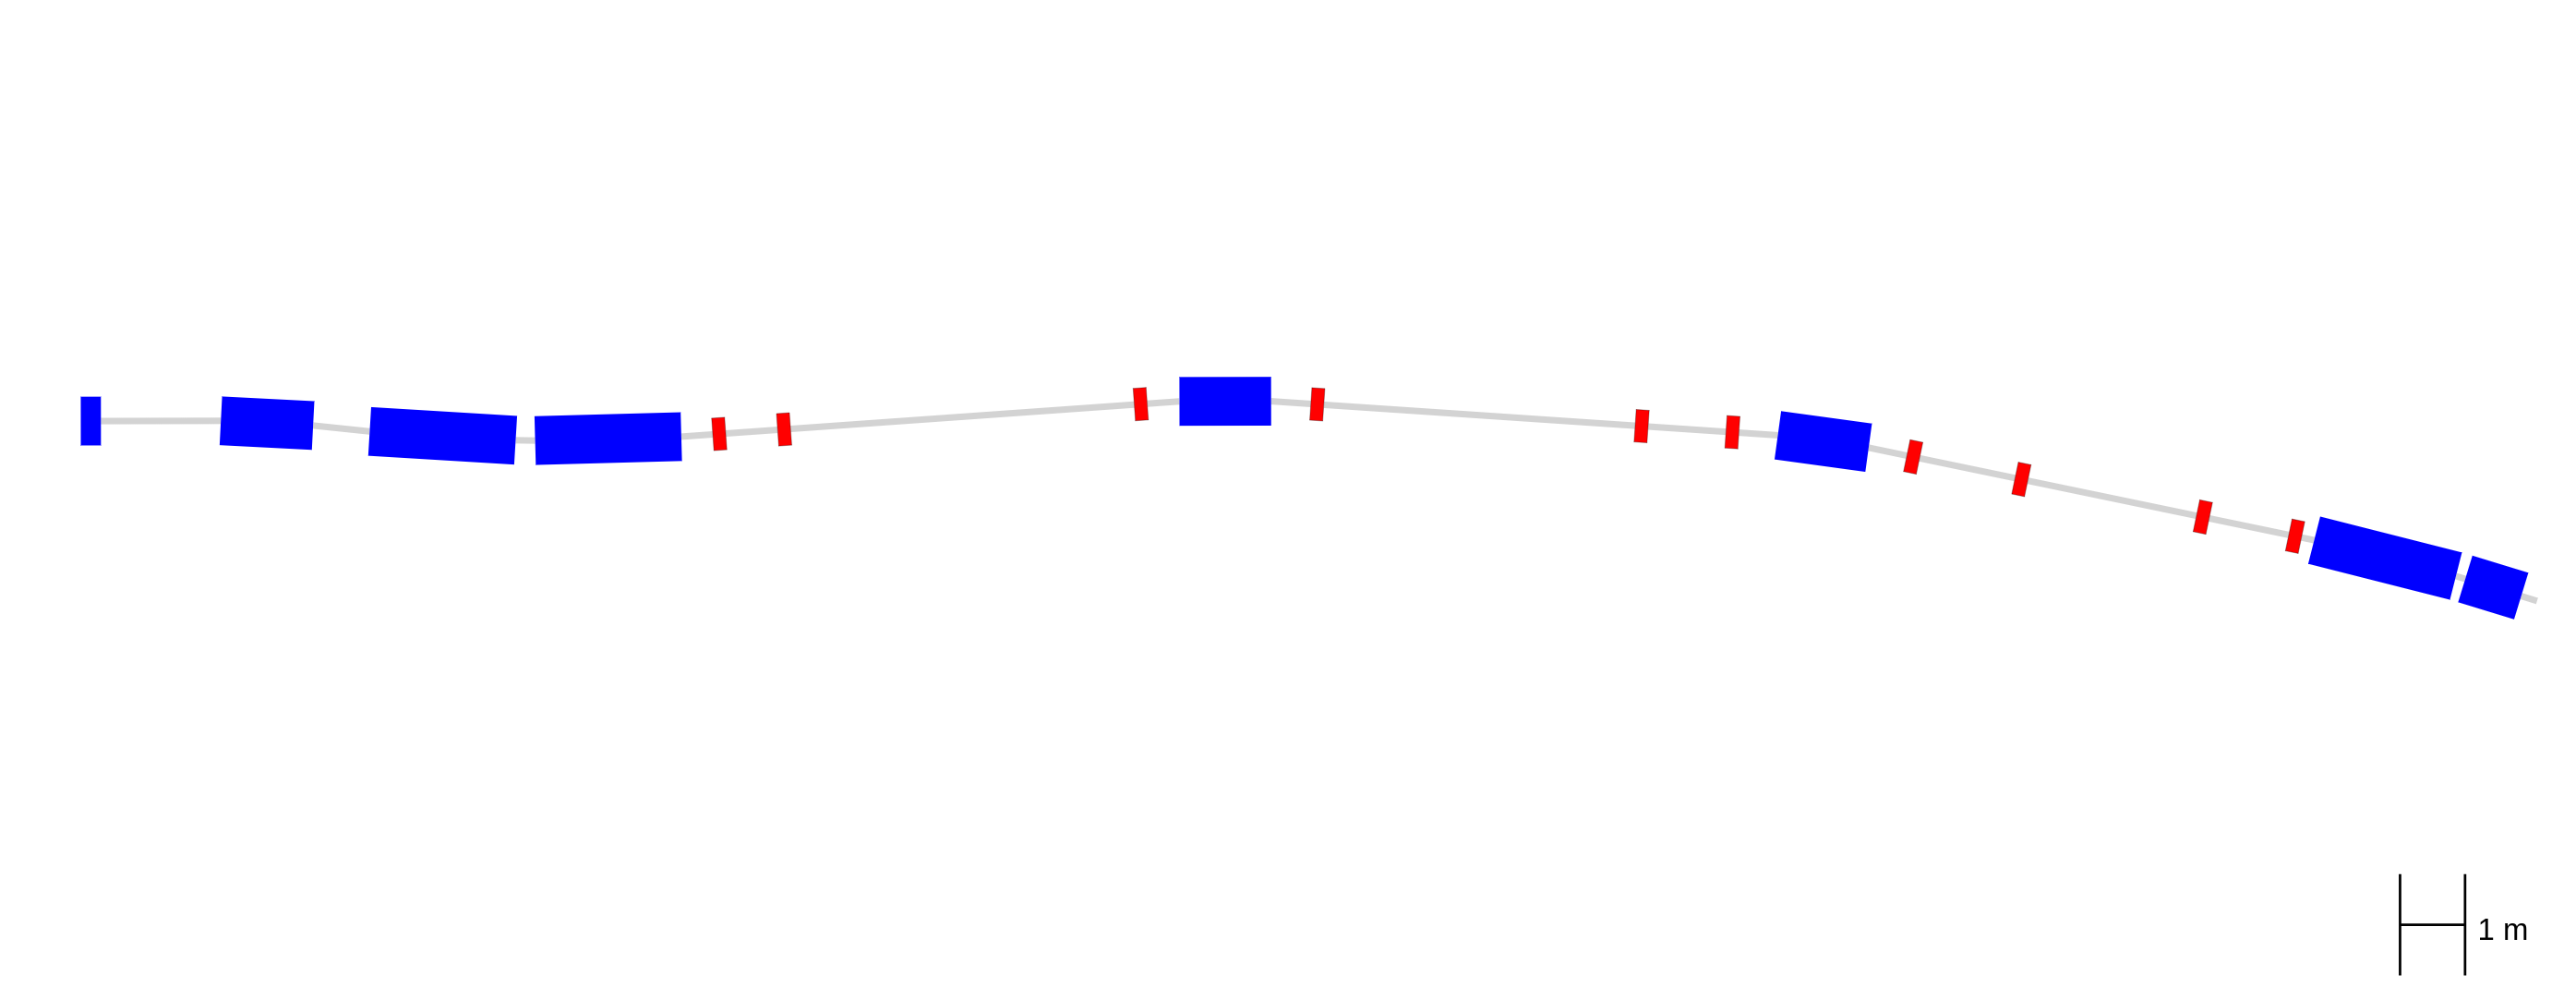

In [9]:
from IPython.display import Image
Image('img/lattice/Lattice-bts.png')

In [10]:
bts_lattice0 = at.Lattice(
    [kext, dr1, bm1, dr2, sepext, dr3, sepext, dr4, q11, dr4_1, q12,
     dr4_2, q13, dr4_3, btsbm, dr5, q21, dr5_2, q22, dr5_3, q23, dr5_4,
     btsbm, dr6, q31, dr6_1, q32, dr6_2, q33, dr6_3, q34, dr6_4, sepsr, 
     dr7, sepsr2, dr_nkm_up_bts],
    name="BTS Lattice", particle='relativistic', energy=4e9
)

In [11]:
m44, _ = at.find_m44(bts_lattice0, 0)
print(m44)

[[-0.84874747  0.10500027  0.          0.        ]
 [-0.32705036 -1.13774669  0.          0.        ]
 [ 0.          0.         -8.73048569 44.16924156]
 [ 0.          0.         -0.71813082  3.51862366]]


In [12]:
m66, _ = at.find_m66(bts_lattice0, 0)
print(m66)

[[-8.48747469e-01  1.05000269e-01  0.00000000e+00  0.00000000e+00
  -1.28815219e+00  0.00000000e+00]
 [-3.27050355e-01 -1.13774669e+00  0.00000000e+00  0.00000000e+00
  -3.28630854e-03  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -8.73048569e+00  4.41692416e+01
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -7.18130817e-01  3.51862366e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00]
 [-4.18501386e-01 -1.46593596e+00  0.00000000e+00  0.00000000e+00
  -2.49885506e-01  1.00000000e+00]]


In [13]:
## List of lattice elements
#index = 0
#for elem in bts_lattice:
#    print(index, elem.FamName)
#    index += 1

## BTS Lattice with Apertures

In [14]:
bts_lattice_aperture = bts_lattice0.copy()
at_drift = np.nonzero(at.get_cells(bts_lattice_aperture, at.checktype(at.Drift)))
accum = 0
for i in np.nditer(at_drift):
    bts_lattice_aperture[i+accum:i+1+accum] = [ap_drift, bts_lattice_aperture[i+accum], ap_drift]
    accum += 2

at_quad = np.nonzero(at.get_cells(bts_lattice_aperture, at.checktype(at.Quadrupole)))
accum = 0
for i in np.nditer(at_quad):
    bts_lattice_aperture[i+accum:i+1+accum] = [ap_quad, bts_lattice_aperture[i+accum], ap_quad]
    accum += 2

at_bend = np.nonzero(at.get_cells(bts_lattice_aperture, at.checktype(at.Bend)))
accum = 0
for i in np.nditer(at_bend):
    bts_lattice_aperture[i+accum:i+accum+1] = [ap_bend, bts_lattice_aperture[i+accum], ap_bend]
    accum += 2

In [15]:
## check aperture location for elements
#at_aperture = np.nonzero(at.get_cells(bts_lattice_aperture, at.checktype(at.Drift)))
#sum = 0
#for i in np.nditer(at_aperture):
#    print(bts_lattice_aperture[i-1].FamName, bts_lattice_aperture[i].FamName)
#    sum += 1
#print("the number of apetures is:", sum)

In [16]:
m44_aperture, _ = at.find_m44(bts_lattice_aperture, 0)
print(m44_aperture)

[[-0.84874747  0.10500027  0.          0.        ]
 [-0.32705036 -1.13774669  0.          0.        ]
 [ 0.          0.         -8.73048569 44.16924156]
 [ 0.          0.         -0.71813082  3.51862366]]


In [17]:
## List of lattice elements
#index = 0
#for elem in bts_lattice_aperture:
#    print(index, elem.FamName)
#    index += 1

In [18]:
# add drift space the upstream of the nkm element and add aperture
has_aperture = True
if has_aperture:
    bts_lattice = bts_lattice_aperture.copy()
else:
    bts_lattice = bts_lattice0.copy()

print (len(bts_lattice), len(bts_lattice_aperture), len(bts_lattice0))

108 108 36


## Plotting Lattice Functions

In [19]:
# Initial Twiss parameters
initial_twiss_parameters = {
    'beta': [7.560000, 12.269000],  # [beta_x, beta_y] in meters
    'alpha': [1.5231000, -1.654700],   # [alpha_x, alpha_y]
    'dispersion': [0.2762000, -0.0657000, 0.0, 0.0]  # [Dx, Dpx, Dy, Dpy] in meters and radians
}

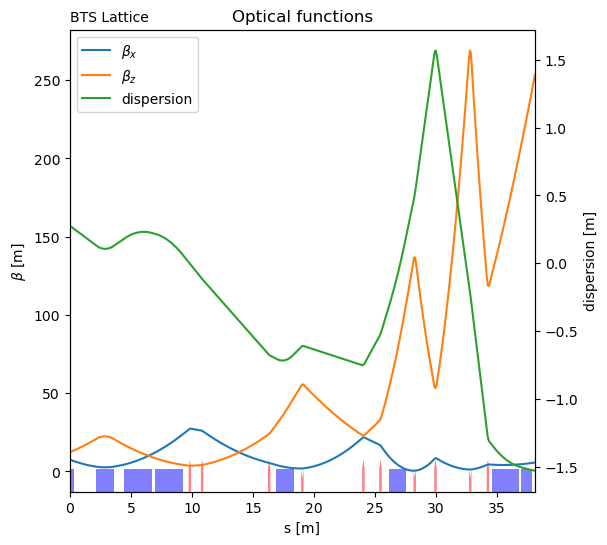

(<Axes: title={'left': 'BTS Lattice', 'center': 'Optical functions'}, xlabel='s [m]', ylabel='$\\beta$ [m]'>,
 <Axes: ylabel='dispersion [m]'>,
 <Axes: >)

In [20]:
bts_lattice0.plot_beta(twiss_in=initial_twiss_parameters)

## Fitting Lattice Functions

### Load Storage Ring Lattice and Extract Lattice Functions at the injection point

In [21]:
# load original storage ring lattice
original_storage_ring_lattice = at.load_mat('K4GSR_HBIv4-1.mat')

# remove the first drift element from the storage ring lattice to add NKM
section_start = original_storage_ring_lattice[0]
section_end = original_storage_ring_lattice[-1]
len(original_storage_ring_lattice)
# This removes the first drift element and first and last markers
storage_ring_lattice = original_storage_ring_lattice[2:len(original_storage_ring_lattice)-1]

# Define a new drift element to add at the end of the lattice
dr_nkm_up_ring = at.Drift('NKMUPRING', 2.0)       # a drift element upstream of nkm
dr_nkm = at.Drift('NKM', 0.525)           # NKM element
dr_nkm_down = at.Drift('NKMDOWN', 0.175)  # a drift element downstream of nkm

# append the drift elements to the end of the modified storage ring lattice
storage_ring_lattice.append(dr_nkm_up_ring)
storage_ring_lattice.append(section_end)

# insert drift elements to the begiining of modified storage ring lattice
storage_ring_lattice.insert(0, dr_nkm_down)
storage_ring_lattice.insert(0, dr_nkm)
storage_ring_lattice.insert(0, section_start)
                            
# Optionally, save the modified lattice to a file for future use
at.save_mat(storage_ring_lattice, 'storage_ring_lattice_nkm.mat')

In [22]:
# Check newly added elements
index = 0
for elem in storage_ring_lattice:
    if index < 4 or index > 3478:
        print (index, elem)
    index += 1

print ("total numbers of lattices:", len(original_storage_ring_lattice), len(storage_ring_lattice))

# Calculate the total circumference by summing up the lengths of all elements
total_circumference_orig = sum(element.Length for element in original_storage_ring_lattice if hasattr(element, 'Length'))
total_circumference = sum(element.Length for element in storage_ring_lattice if hasattr(element, 'Length'))

# Print the total circumference
print(f'Total circumference of the original storage ring: {total_circumference_orig:.3f} meters')
print(f'Total circumference of the storage ring: {total_circumference:.3f} meters')

0 Marker:
       FamName: SectionStart
        Length: 0.0
    PassMethod: IdentityPass
1 Drift:
       FamName: NKM
        Length: 0.525
    PassMethod: DriftPass
2 Drift:
       FamName: NKMDOWN
        Length: 0.175
    PassMethod: DriftPass
3 Quadrupole:
       FamName: QH1
        Length: 0.2
    PassMethod: StrMPoleSymplectic4Pass
      MaxOrder: 1
   NumIntSteps: 10
      PolynomA: [0. 0.]
      PolynomB: [0.       1.283948]
             K: 1.283948
3479 Quadrupole:
       FamName: QH1
        Length: 0.2
    PassMethod: StrMPoleSymplectic4Pass
      MaxOrder: 1
   NumIntSteps: 10
      PolynomA: [0. 0.]
      PolynomB: [0.       1.283948]
             K: 1.283948
3480 Drift:
       FamName: LH1
        Length: 2.7
    PassMethod: DriftPass
3481 Drift:
       FamName: NKMUPRING
        Length: 2.0
    PassMethod: DriftPass
3482 Marker:
       FamName: SectionEnd
        Length: 0.0
    PassMethod: IdentityPass
total numbers of lattices: 3481 3483
Total circumference of the orig

In [23]:
refpts = storage_ring_lattice.get_cells(at.checkname('NKM'))
print("reference points:", list(storage_ring_lattice[refpts]))
elemdata0, *_ = storage_ring_lattice.get_optics(refpts=refpts)
betax_inj, betay_inj = elemdata0['beta']
alphax_inj, alphay_inj = elemdata0['alpha']
dispersionx_inj, dispersionxp_inj, *_ = elemdata0['dispersion']

#############################################################################
# Scaling betatron function objectives 
# These numbers should be computed from storage ring dynamics
# However to test the NKM beam dynamics I set these numbers intentionally

scale_beta = 0.1
scale_alpha = 0.1

betax_inj_mod = scale_beta * betax_inj
alphax_inj_mod = scale_alpha * alphax_inj
#############################################################################

print("beta_x at injection: %5f" % betax_inj)
print("beta_y at injection: %5f" % betay_inj)
print("alpha_x at injection: %5f" % alphax_inj)
print("alpha_y at injection: %5f" % alphay_inj)
print("dipsersion_x at injection: %5f" % dispersionx_inj)
print("dipsersion_xp at injection: %5f" % dispersionxp_inj)

reference points: [Drift('NKM', 0.525)]
beta_x at injection: 16.202245
beta_y at injection: 5.346832
alpha_x at injection: -0.128508
alpha_y at injection: -0.450454
dipsersion_x at injection: 0.000330
dipsersion_xp at injection: 0.000000


In [24]:
# Desired Twiss parameters and dispersion at the end of the lattice
desired_twiss_param = {
    'beta': [betax_inj_mod, betay_inj],   # Target beta values at the end [beta_x, beta_y]
    'alpha': [alphax_inj_mod, alphay_inj],    # Target alpha values at the end [alpha_x, alpha_y]
    'dispersion': [dispersionx_inj, dispersionxp_inj]  # Target dispersion at the end [Dx, Dy]
}
print (desired_twiss_param)

{'beta': [np.float64(1.6202244542247695), np.float64(5.346832259976539)], 'alpha': [np.float64(-0.012850849480222663), np.float64(-0.45045421289448256)], 'dispersion': [np.float64(0.0003304468808631982), np.float64(4.6368737489844133e-07)]}


In [25]:
# Function to set quadrupole strengths
def set_quadrupole_strengths(strengths):
    q11.K, q12.K, q13.K, q21.K, q22.K, q23.K, q31.K, q32.K, q33.K = strengths

In [26]:
# Objective function for optimization
def objective_function(strengths):
    # Set the quadrupole strengths
    set_quadrupole_strengths(strengths)
    
    # Perform linear optics analysis using linopt6
    linopt0, latopt, linopt = at.linopt6(bts_lattice, refpts=len(bts_lattice), twiss_in=initial_twiss_parameters)
    
    # Extract beta, alpha, and dispersion values at the end of the lattice
    beta_end = linopt['beta'][-1]  # [beta_x, beta_y] at the end of the lattice
    alpha_end = linopt['alpha'][-1]  # [alpha_x, alpha_y] at the end of the lattice
    dispersion_end = linopt['dispersion'][-1]  # [Dx, Dpx, Dy, Dpy] at the end of the lattice
    
    # Calculate the cost function as the sum of squared differences for both planes (horizontal and vertical)
    beta_diff = (beta_end[0] - desired_twiss_param['beta'][0])**2 + (beta_end[1] - desired_twiss_param['beta'][1])**2
    alpha_diff = (alpha_end[0] - desired_twiss_param['alpha'][0])**2 + (alpha_end[1] - desired_twiss_param['alpha'][1])**2
    
    # Add dispersion term to the cost function (target is zero dispersion in x-plane)
    global opt_dispersion
    dx_diff = 0
    if opt_dispersion:
        dx_diff = (dispersion_end[0] - desired_twiss_param['dispersion'][0])**2
    
    # Return the combined cost function
    return beta_diff + alpha_diff + dx_diff

In [27]:
# Callback function to display iteration progress
iteration_counter = [0]  # Use a list to make the counter mutable in the callback function

def callback_function(x):
    iteration_counter[0] += 1
    print(f"Iteration {iteration_counter[0]}: Current strengths = {x}")

In [28]:
# Constraints for beta_x and beta_y to ensure they are less than set value
beta_max = 60
def constraint_beta_x(strengths):
    set_quadrupole_strengths(strengths)
    linopt0, latopt, linopt = at.linopt6(bts_lattice, refpts=len(bts_lattice), twiss_in=initial_twiss_parameters)
    beta_end = linopt['beta'][-1]
    return beta_max - beta_end[0]  # beta_x must be less than 60 (positive if constraint is satisfied)

def constraint_beta_y(strengths):
    set_quadrupole_strengths(strengths)
    linopt0, latopt, linopt = at.linopt6(bts_lattice, refpts=len(bts_lattice), twiss_in=initial_twiss_parameters)
    beta_end = linopt['beta'][-1]
    return beta_max - beta_end[1]  # beta_y must be less than 60 (positive if constraint is satisfied)

In [29]:
# Options for optimizations

# Initial guess for quadrupole strengths
#initial_guess = [q11.K, q12.K, q13.K, q21.K, q22.K, q23.K, q31.K, q32.K, q33.K]
initial_guess = original_strengths

print ("initial quadrupole strengths:", initial_guess)

# Define constraints as a list of dictionaries
constraints = [
    {'type': 'ineq', 'fun': constraint_beta_x},  # beta_x < 60
    {'type': 'ineq', 'fun': constraint_beta_y}   # beta_y < 60
]

# Use either of following methods (Nelder-Mead, Powell, COBYLA)
# To add constraints, use only the COBYLA method
optimization_method = 'Nelder-Mead'
has_constraints = True
if optimization_method != "COBYLA":
    has_constraints = False

print ("Optimization Method:", optimization_method)
print ("has_constraints", has_constraints)
opt_dispersion = True

max_iter = 10000

initial quadrupole strengths: (0.738, 0.415, 0.415, -0.9902, 1.288, 1.288, -2.08, 4.13, -2.24)
Optimization Method: Nelder-Mead
has_constraints False


In [30]:
run_optimization = False

if run_optimization:
    t0 = time.time()
    if has_constraints:
        result = minimize(objective_function, initial_guess, method=optimization_method, options={'maxiter': max_iter, 'disp': True}, constraints=constraints)
        with open('optimized_result_%s_constraints.pkl' % optimization_method, 'wb') as f:
            pickle.dump(result, f)
    else:
        result = minimize(objective_function, initial_guess, method=optimization_method, options={'maxiter': max_iter, 'disp': True})
        with open('optimized_result_%s.pkl' % optimization_method, 'wb') as f:
            pickle.dump(result, f)
    t1 = time.time()
    print((t1-t0), "seconds to optimize")
else:
    print("Skipping slow optimization cell. Utilizing refactored SLSQP optimizer results.")


Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 830
         Function evaluations: 1253
38.01312708854675 seconds to optimize


In [31]:
# Load the result object using pickle or fall back to modular refactored optimization results
import os
import json

filename = 'optimized_result_%s_constraints.pkl' % optimization_method if has_constraints else 'optimized_result_%s.pkl' % optimization_method

if os.path.exists(filename):
    with open(filename, 'rb') as f:
        loaded_result = pickle.load(f)
    optimized_strengths = loaded_result.x
elif os.path.exists('results/bts_optimization/bts_optimization_results.json'):
    with open('results/bts_optimization/bts_optimization_results.json', 'r') as f:
        opt_data = json.load(f)
    optimized_strengths = opt_data["best_solution"]["strengths"]
else:
    # SLSQP-optimized fallback strengths from src.nkm
    optimized_strengths = [0.47419899, -1.70822248, 1.33402498, -1.05419705, 1.63861169, -0.98192641, 1.08602944, -1.67069631, 0.92706350]

# Set the optimized quadrupole strengths to the lattice
set_quadrupole_strengths(optimized_strengths)

# Print the results
print("Original quadrupole strengths:", ", ".join([f"{float(x):.5f}" for x in original_strengths]))
print("Optimized quadrupole strengths:", ", ".join([f"{float(x):.5f}" for x in optimized_strengths]))


Original quadrupole strengths: 0.73800, 0.41500, 0.41500, -0.99020, 1.28800, 1.28800, -2.08000, 4.13000, -2.24000
Optimized quadrupole strengths: 1.15865, -0.05010, 0.49795, -1.44650, 1.89085, -0.54496, -2.44678, 3.31202, -2.81762
Optimization Method: Nelder-Mead
Objective function value at optimum: 0.0003316110020911634


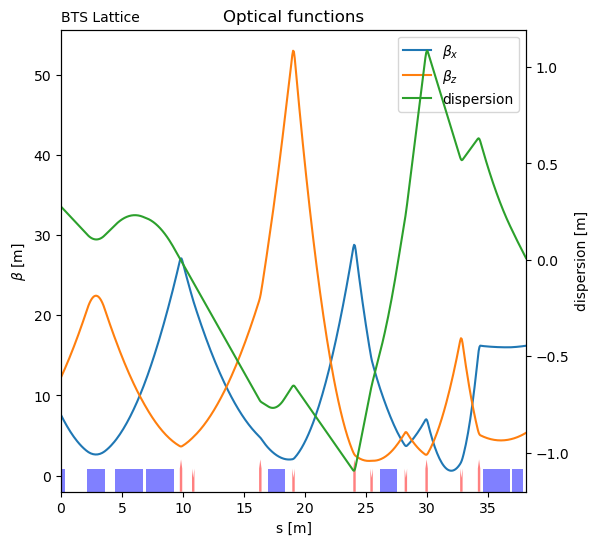

(<Axes: title={'left': 'BTS Lattice', 'center': 'Optical functions'}, xlabel='s [m]', ylabel='$\\beta$ [m]'>,
 <Axes: ylabel='dispersion [m]'>,
 <Axes: >)

In [32]:
bts_lattice.plot_beta(twiss_in=initial_twiss_parameters)

In [33]:
linopt0, latopt, linopt = at.linopt6(bts_lattice, refpts=len(bts_lattice), twiss_in=initial_twiss_parameters)
# Extract beta, alpha, and dispersion values at the end of the lattice
beta_end = linopt['beta'][-1]  # [beta_x, beta_y] at the end of the lattice
alpha_end = linopt['alpha'][-1]  # [alpha_x, alpha_y] at the end of the lattice
dispersion_end = linopt['dispersion'][-1]  # [Dx, Dpx, Dy, Dpy] at the end of the lattice

print ("Target beta at the BTS end:", elemdata0['beta'])
print ("Target alpha at the BTS end:", elemdata0['alpha'])
print ("Target dipsersion at the BTS end:", elemdata0['dispersion'])
print ("Optimized beta at the BTS end:", beta_end)
print ("Optimized alpha at the BTS end:", alpha_end)
print ("Optimized dispersion at the BTS end:", dispersion_end)

Target beta at the BTS end: [16.20224454  5.34683226]
Target alpha at the BTS end: [-0.12850849 -0.45045421]
Target dipsersion at the BTS end: [3.30446881e-04 4.63687375e-07 5.46768128e-16 1.70862161e-16]
Optimized beta at the BTS end: [16.20265336  5.34631145]
Optimized alpha at the BTS end: [-0.11602271 -0.4601536 ]
Optimized dispersion at the BTS end: [ 0.00934154 -0.12258401  0.          0.        ]


## Generate Beam Distributions

### Beam distribution at the entrance of BTS

In [34]:
beam_sigma_mat = at.sigma_matrix(
    betax = 7.560000,
    alphax = 1.5231000,
    emitx = 10.89e-9,
    betay = 12.269000,
    alphay = -1.654700,
    emity = 10.89e-9,
    blength = 13.4e-3,
    espread = 1.1e-3    
)
print(beam_sigma_mat)

num_particles = 10000
init_beam = at.beam(num_particles, beam_sigma_mat)
print(init_beam.shape)

[[ 8.23284000e-08 -1.65865590e-08  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-1.65865590e-08  4.78214127e-09  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.33609410e-07  1.80196830e-08
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.80196830e-08  3.31788813e-09
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.21000000e-06  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.79560000e-04]]
h, v, delta
(6, 10000)


### Circulating beam distributions

In [35]:
circulating_beam_sigma_mat = at.sigma_matrix(
    betax = betax_inj,
    alphax = alphax_inj,
    emitx = 10.89e-9,
    betay = betay_inj,
    alphay = alphay_inj,
    emity = 10.89e-9,
    blength = 13.4e-3,
    espread = 1.1e-3    
)
print(circulating_beam_sigma_mat)

num_particles = 10000
init_beam_circulating = at.beam(num_particles, circulating_beam_sigma_mat)
print(init_beam_circulating.shape)

[[1.76442443e-07 1.39945751e-09 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.39945751e-09 6.83228929e-10 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.82270033e-08 4.90544638e-09
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 4.90544638e-09 2.44998877e-09
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.21000000e-06 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 1.79560000e-04]]
h, v, delta
(6, 10000)


## Beam Tracking

In [36]:
beam_tracking = at.lattice_track(bts_lattice, init_beam, 1)
final_beam = beam_tracking[1]['rout']
print(init_beam.shape, final_beam.shape)
print(init_beam[:,0], final_beam[:,0])

(6, 10000) (6, 10000)
[-6.67476502e-06 -4.56766136e-05  6.70710631e-05 -6.50203258e-05
  9.79828815e-04 -4.27195149e-03] [-4.85071550e-04 -1.06116798e-04  2.52691924e-04 -8.00137874e-05
  9.79828815e-04 -4.35009604e-03]


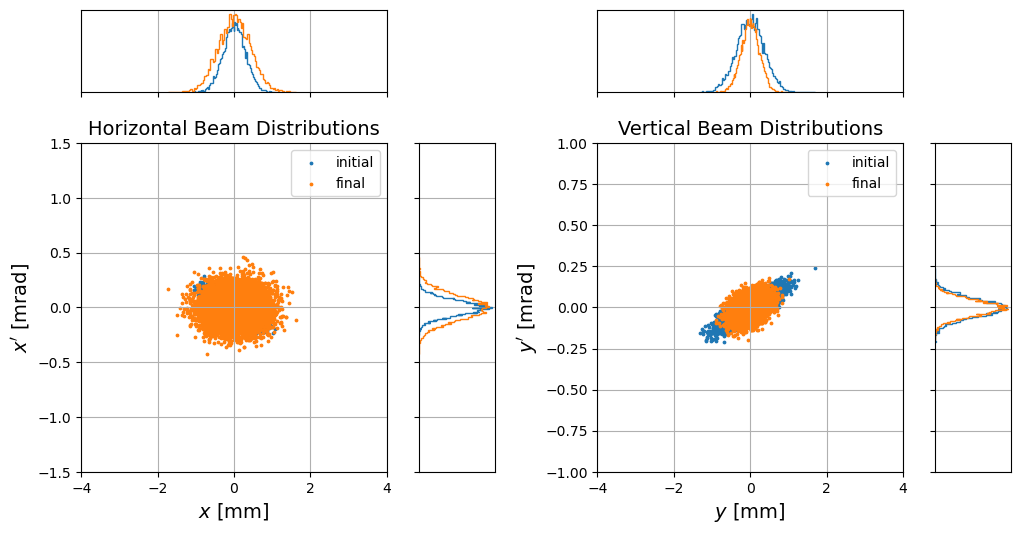

In [37]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Setup figure with custom GridSpec layout
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 5, width_ratios=[4, 1, 0.5, 4, 1], height_ratios=[1, 4], hspace=0.25, wspace=0.2)

# Horizontal phase space
ax_histx = fig.add_subplot(gs[0, 0], sharex=None)
ax_histy = fig.add_subplot(gs[1, 1], sharey=None)
ax_main_x = fig.add_subplot(gs[1, 0], sharex=ax_histx)

# Vertical phase space
ax_histx2 = fig.add_subplot(gs[0, 3], sharex=None)
ax_histy2 = fig.add_subplot(gs[1, 4], sharey=None)
ax_main_y = fig.add_subplot(gs[1, 3], sharex=ax_histx2)

# -- Horizontal main scatter
ax_main_x.set_title('Horizontal Beam Distributions', fontsize=14)
ax_main_x.scatter(init_beam[0, :]*1e3, init_beam[1, :]*1e3, s=3, label='initial')
ax_main_x.scatter(final_beam[0, :]*1e3, final_beam[1, :]*1e3, s=3, label='final')
ax_main_x.set_xlabel(r'$x$ [mm]', fontsize=14)
ax_main_x.set_ylabel(r"$x'$ [mrad]", fontsize=14)
ax_main_x.set_xlim([-4, 4])
ax_main_x.set_ylim([-1.5, 1.5])
ax_main_x.grid(True)
ax_main_x.legend(loc='best', fontsize=10)

# Horizontal top projection
ax_histx.hist(init_beam[0, :]*1e3, bins=100, histtype='step')
ax_histx.hist(final_beam[0, :]*1e3, bins=100, histtype='step')
ax_histx.grid(True)
ax_histx.set_yticks([])
ax_histx.tick_params(labelbottom=False)  # hide tick labels only, keep ticks

# Horizontal right projection
ax_histy.hist(init_beam[1, :]*1e3, bins=100, orientation='horizontal', histtype='step')
ax_histy.hist(final_beam[1, :]*1e3, bins=100, orientation='horizontal', histtype='step')
ax_histy.grid(True)
ax_histy.set_xticks([])
ax_histy.set_ylim(ax_main_x.get_ylim())
ax_histy.tick_params(labelleft=False)  # show y-axis labels

# -- Vertical main scatter
ax_main_y.set_title('Vertical Beam Distributions', fontsize=14)
ax_main_y.scatter(init_beam[2, :]*1e3, init_beam[3, :]*1e3, s=3, label='initial')
ax_main_y.scatter(final_beam[2, :]*1e3, final_beam[3, :]*1e3, s=3, label='final')
ax_main_y.set_xlabel(r'$y$ [mm]', fontsize=14)
ax_main_y.set_ylabel(r"$y'$ [mrad]", fontsize=14)
ax_main_y.set_xlim([-4, 4])
ax_main_y.set_ylim([-1, 1])
ax_main_y.grid(True)
ax_main_y.legend(loc='best', fontsize=10)

# Vertical top projection
ax_histx2.hist(init_beam[2, :]*1e3, bins=100, histtype='step')
ax_histx2.hist(final_beam[2, :]*1e3, bins=100, histtype='step')
ax_histx2.grid(True)
ax_histx2.set_yticks([])
ax_histx2.tick_params(labelbottom=False)

# Vertical right projection
ax_histy2.hist(init_beam[3, :]*1e3, bins=100, orientation='horizontal', histtype='step')
ax_histy2.hist(final_beam[3, :]*1e3, bins=100, orientation='horizontal', histtype='step')
ax_histy2.grid(True)
ax_histy2.set_xticks([])
ax_histy2.set_ylim(ax_main_y.get_ylim())
ax_histy2.tick_params(labelleft=False)

fig.savefig('img/beam_distributions_through_bts_with_projections.png', dpi=fig.dpi)
plt.show()

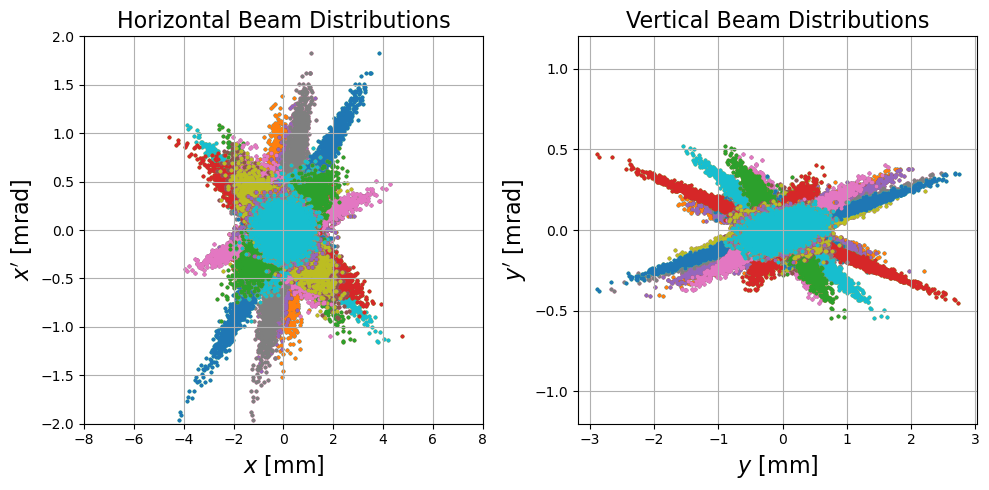

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs = axs.flatten()

r_in = init_beam.copy()

axs[0].set_title('Horizontal Beam Distributions', fontsize=16)
axs[0].scatter(r_in[0,:]*1e3, r_in[1,:]*1e3, s=3)
axs[0].scatter(r_in[0,:]*1e3, r_in[1,:]*1e3, s=3)
axs[0].set_xlabel(r'$x$ [mm]', fontsize=16)
axs[0].set_ylabel(r'$x^{\prime}$ [mrad]', fontsize=16)
axs[0].set_xlim([-8, 8])
axs[0].set_ylim([-2, 2])
axs[0].grid()

axs[1].set_title('Vertical Beam Distributions', fontsize=16)
axs[1].scatter(r_in[2,:]*1e3, r_in[3,:]*1e3, s=3)
axs[1].scatter(r_in[2,:]*1e3, r_in[3,:]*1e3, s=3)
axs[1].set_xlabel(r'$y$ [mm]', fontsize=16)
axs[1].set_ylabel(r'$y^{\prime}$ [mrad]', fontsize=16)
#axs[1].set_xlim([-4, 4])
axs[1].set_ylim([-1.2, 1.2])
axs[1].grid()

for elem in bts_lattice:
    r_out = at.element_track(elem, r_in)
    axs[0].scatter(r_out[0,:]*1e3, r_out[1,:]*1e3, s=3)
    axs[1].scatter(r_out[2,:]*1e3, r_out[3,:]*1e3, s=3)
    r_in = r_out

plt.tight_layout()
fig.savefig('img/beam_distributions_through_bts_by_elements.png', dpi=fig.dpi)

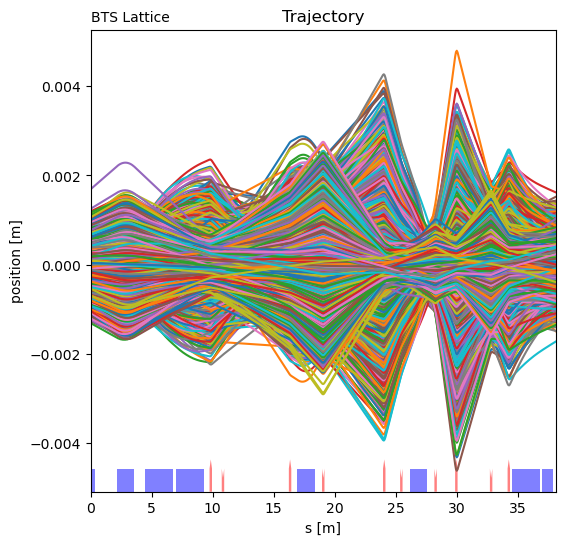

(<Axes: title={'left': 'BTS Lattice', 'center': 'Trajectory'}, xlabel='s [m]', ylabel='position [m]'>,
 None,
 <Axes: >)

In [39]:
## plot trajectory
at.plot.plot_trajectory(bts_lattice, r_in=init_beam.copy(), legend=False)

## Preparing Beam Tracking in the Storage Ring Lattice with a Shifted Beam from the BTS Lattice

In [40]:
# Beam offset and scaling

##############################################

x_offset  = -5.7e-3
xp_offset = 3e-3
scale_factor_x = 0.3
scale_factor_xp = 0.3

###############################################

new_final_beam = final_beam.copy()
new_final_beam[0,:] *= scale_factor_x
new_final_beam[0,:] += x_offset
new_final_beam[1,:] *= scale_factor_xp
new_final_beam[1,:] += xp_offset

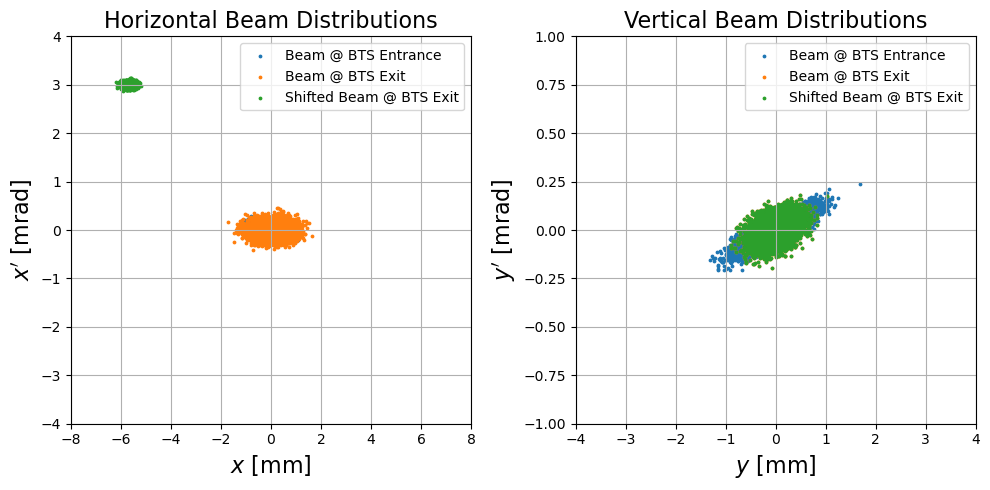

In [41]:
labels = ['Beam @ BTS Entrance', 'Beam @ BTS Exit', 'Shifted Beam @ BTS Exit']
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs = axs.flatten()

axs[0].set_title('Horizontal Beam Distributions', fontsize=16)
axs[0].scatter(init_beam[0,:]*1e3, init_beam[1,:]*1e3, s=3, label=labels[0])
axs[0].scatter(final_beam[0,:]*1e3, final_beam[1,:]*1e3, s=3, label=labels[1])
axs[0].scatter(new_final_beam[0,:]*1e3, new_final_beam[1,:]*1e3, s=3, label=labels[2])
axs[0].set_xlabel(r'$x$ [mm]', fontsize=16)
axs[0].set_ylabel(r'$x^{\prime}$ [mrad]', fontsize=16)
axs[0].set_xlim([-8, 8])
axs[0].set_ylim([-4, 4])
axs[0].grid()
axs[0].legend(loc='best')

axs[1].set_title('Vertical Beam Distributions', fontsize=16)
axs[1].scatter(init_beam[2,:]*1e3, init_beam[3,:]*1e3, s=3, label=labels[0])
axs[1].scatter(final_beam[2,:]*1e3, final_beam[3,:]*1e3, s=3, label=labels[1])
axs[1].scatter(new_final_beam[2,:]*1e3, new_final_beam[3,:]*1e3, s=3, label=labels[2])
axs[1].set_xlabel(r'$y$ [mm]', fontsize=16)
axs[1].set_ylabel(r'$y^{\prime}$ [mrad]', fontsize=16)
axs[1].set_xlim([-4, 4])
axs[1].set_ylim([-1, 1])
axs[1].grid()
axs[1].legend(loc='best')

plt.tight_layout()
fig.savefig('img/beam_distributions_shifted.png', dpi=fig.dpi)

## Load NKM Field Data from Excel File

In [42]:
# Load the Excel file
file_path = 'nkm_field.xlsx'
data = pd.read_excel(file_path)

In [43]:
# Load the txt file
data2 = pd.read_csv("By.txt", sep=" ", header = None)
data2.columns = ['x', 'By']

In [44]:
# Rename columns for easier access
data.columns = ['x', 'By']

# Expand data with origin symmetry (mirror over both axes)
x_original = data['x']
By_original = data['By']

# Create symmetric data by mirroring the original data over both axes (x and y)
x_mirrored = -x_original[::-1]
By_mirrored = -By_original[::-1]

# Combine original and mirrored data
x_expanded_origin = np.concatenate([x_mirrored, x_original])
By_expanded_origin = np.concatenate([By_mirrored, By_original])

# Create a DataFrame for expanded data with origin symmetry
expanded_data_origin = pd.DataFrame({'x': x_expanded_origin, 'By': By_expanded_origin})

# Save the expanded data to an Excel file
output_file_path = 'nkm_field_expanded.xlsx'
expanded_data_origin.to_excel(output_file_path, index=False)

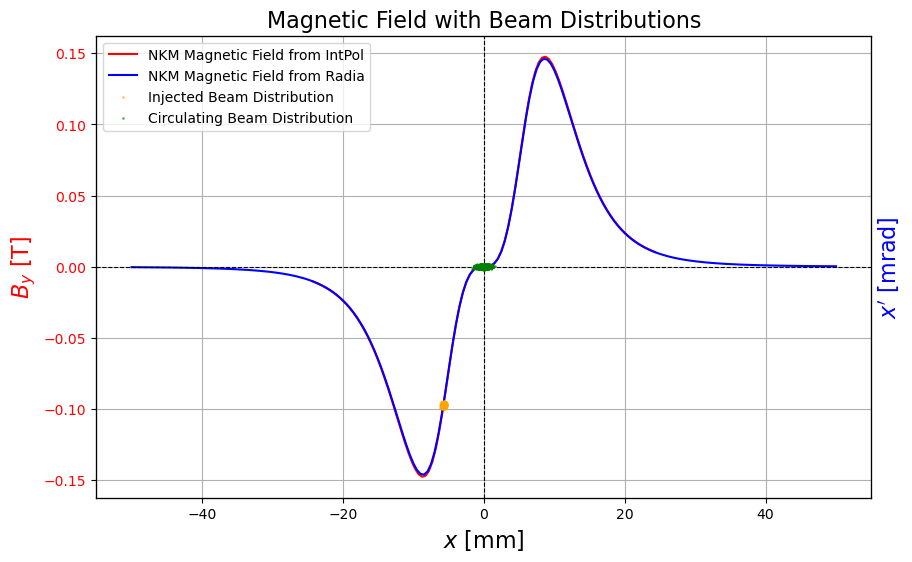

In [45]:
# Plotting the expanded data with origin symmetry and adding beam distribution
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotting the expanded magnetic field data
ax1.plot(expanded_data_origin['x']*1e3, expanded_data_origin['By'], color='r', label='NKM Magnetic Field from IntPol')
ax1.plot(data2['x']*1e3, data2['By'], color='b', label='NKM Magnetic Field from Radia')
ax1.set_xlabel(r'$x$ [mm]', fontsize=16)
ax1.set_ylabel(r'$B_y$ [T]', fontsize=16, color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.grid(True)

# Creating a secondary y-axis to plot the beam distribution
ax2 = ax1.twinx()
ax2.scatter(new_final_beam[0, :]*1e3, new_final_beam[1, :]*1e3, s=1, alpha=0.5, color='orange', label='Injected Beam Distribution')
ax2.set_ylabel(r'$x^\prime$ [mrad]', fontsize=16, color='b')
ax2.set_ylim([0, 15])
ax2.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)

ax3 = ax1.twinx()
ax3.scatter(init_beam_circulating[0, :]*1e3, init_beam_circulating[1, :]*1e3, s=1, alpha=0.5, color='g', label='Circulating Beam Distribution')
ax3.set_ylim([-7.5, 7.5])
ax3.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)


fig.legend(loc="upper left", bbox_to_anchor=(0, 1), bbox_transform=ax1.transAxes)
plt.title('Magnetic Field with Beam Distributions', fontsize=16)
fig.savefig('img/beam_with_bfield.png', dpi=fig.dpi)

## Particle Tracking through the NKM Element

In [46]:
# Load and prepare data (assuming expanded_data_origin is already defined)
x_field = expanded_data_origin['x'].values
By_field = expanded_data_origin['By'].values

# Remove duplicates from x_field
unique_indices = np.unique(x_field, return_index=True)[1]
x_field_unique = x_field[unique_indices]
By_field_unique = By_field[unique_indices]

# Create an interpolation function for the By field
By_interpolation = interp1d(x_field_unique, By_field_unique, kind='cubic', fill_value='extrapolate')

### Numerical integration to propagate each particle through the NKM

In an ideal implementation of the drift-kick approach for symplectic integration,
- Drift based on the initial momentum, which updates the position.
- Kick should be computed based on the initial position, 
This sequence corresponds to applying a force over a small displacement to preserve the Hamiltonian structure.

In symplectic integration, the kick should indeed be computed based on the initial position before drifting. 
This is because the force (kick) is based on the field experienced at the particle's current position, not the future position.
The drift then propagates the particle's position based on its initial momentum.

The drift is computed based on the initial momentum of the particle, reflecting the motion of the particle through the drift region before the impact of the magnetic field changes its direction. The kick is applied based on the initial position to reflect the force applied by the magnetic field, resulting in a change in momentum. This approach preserves the symplectic nature of the system, ensuring that the dynamics are accurately modeled. In Hamiltonian systems (like particle motion in accelerators), it is important to maintain consistency in how position and momentum updates are applied. Using the initial position for the kick and then updating the momentum ensures that the Hamiltonian structure of the system is preserved. The drift then uses the initial momentum to update the position.

In [47]:
q = -e       # Charge of the particle (Coulombs)

reference_energy = bts_lattice.energy
rest_mass_energy = electron_mass * c**2 / e  # E_0 = m_0 * c^2, converted to eV

gamma = 1 + reference_energy / rest_mass_energy
beta = np.sqrt(gamma * gamma - 1) / gamma
unit_conversion = e / c #1 / (gamma * gamma * beta)

reference_momentum_eV = ((reference_energy**2 - rest_mass_energy**2)**0.5)
reference_momentum = unit_conversion * reference_momentum_eV
#print(reference_momentum_eV, reference_momentum)

# Nonlinear Kicker Magnet Parameters
nkm_length = 0.525 # Length of the NKM element
num_steps = 1000    # Number of steps to discretize the magnet length

# Discretize the length of the NKM
step_length = nkm_length / num_steps
z_positions = np.linspace(0, nkm_length, num_steps)

In [48]:
def nkm_tracking(beam_distribution):
    particles = beam_distribution.copy()

    for z in z_positions:
        # Store the initial positions and momenta before the step
        initial_x_positions = particles[0, :]
        initial_xp = particles[1, :]
        initial_y_positions = particles[2, :]
        initial_yp = particles[3, :]
        initial_z_positions = particles[4, :]
        initial_zp = particles[5, :]

        # Calculate the magnetic field at the initial x positions using interpolation
        By_values = By_interpolation(initial_x_positions)  # Get By values for each particle at their respective initial x positions

        # Compute the change in x' (angular divergence) due to the magnetic field with relativistic corrections
        # Delta x' = (- q * B_y * L) / (p_0 * beta * gamma^2)
        delta_xp = - (q * By_values * step_length) / (reference_momentum) # Change in x' (kick)

        # Update the particle angular divergence in the x direction (x')
        particles[1, :] = initial_xp + delta_xp  # Apply the kick to x' based on the initial position

        # Update the x positions of the particles (drift step based on initial x')
        particles[0, :] = initial_x_positions + initial_xp * step_length # Update x positions using drift effect

        # Update y and z positions based on initial p_y and p_z (drift step)
        particles[2, :] = initial_y_positions + initial_yp * step_length # Update y positions using drift effect
        particles[4, :] = initial_z_positions + initial_zp * step_length # Update z positions using drift effect

    #print ((np.max(delta_xp) - np.min(delta_xp))*1e2 * 1e3)

    return (particles.copy())

## New Method for NKM Tracking

In [49]:
# Using interpolated fields from Excel file and RK4
nkm_exit_beam_circulating = nkm_tracking(init_beam_circulating)
nkm_exit_beam = nkm_tracking(new_final_beam)
print ((np.max(new_final_beam[1,:])-np.min(new_final_beam[1,:]))*1e3)
print ((np.max(nkm_exit_beam[1,:])-np.min(nkm_exit_beam[1,:]))*1e3)

0.2648011308114596
1.4697263041808781


In [50]:
# check how much the injected beam is kicked
print ("the injected beam is kicked by %f [mrad]" % np.double(1e3*(np.average(new_final_beam[1,:]) - np.average(nkm_exit_beam[1,:]))))

the injected beam is kicked by 3.164117 [mrad]


In [51]:
import os
import numpy as np
from at.lattice.nonlinear_kicker import NonlinearKicker
from src.nkm.kickmap import NKMKickMap2D

# Define nonlinear kicker parameters
fam_name = "NKM"
length = 0.525  # Kicker length in meters
energy = 4.0
nslice = 10
field_map_file = "field_map.npy"

if not os.path.exists(field_map_file):
    kmap_obj = NKMKickMap2D("kickmap_file.txt")
    fm_2d = kmap_obj.ky_map
    nx, ny = fm_2d.shape
    fm_4d = np.zeros((nx, ny, nslice, 3))
    for iz in range(nslice):
        fm_4d[:, :, iz, 1] = fm_2d
    np.save(field_map_file, fm_4d)

# Create the nonlinear kicker element from a field map file
NKM2 = NonlinearKicker(fam_name, length, energy, nslice, Filename_in=field_map_file)

print(NKM2.Length, NKM2.Energy, NKM2.Nslice)


0.525 4.0 10


In [52]:
init_beam_circulating2 = init_beam_circulating.copy()
init_beam_circulating3 = init_beam_circulating.copy()
new_final_beam2 = new_final_beam.copy()
new_final_beam3 = new_final_beam.copy()

nkm_exit_beam_circulating2 = at.lattice_pass([NKM2], init_beam_circulating2)
nkm_exit_beam_circulating3 = NKM2.track(init_beam_circulating3)

nkm_exit_beam2 = at.lattice_pass([NKM2], new_final_beam2)
nkm_exit_beam3 = NKM2.track(new_final_beam3)

print ((np.max(new_final_beam[1,:])-np.min(new_final_beam[1,:]))*1e3)
print ((np.max(nkm_exit_beam2[1,:])-np.min(nkm_exit_beam2[1,:]))*1e3)
print ((np.max(nkm_exit_beam3[1,:])-np.min(nkm_exit_beam3[1,:]))*1e3)


0.2648011308114596
1.7894074304737533
1.7894074304737533


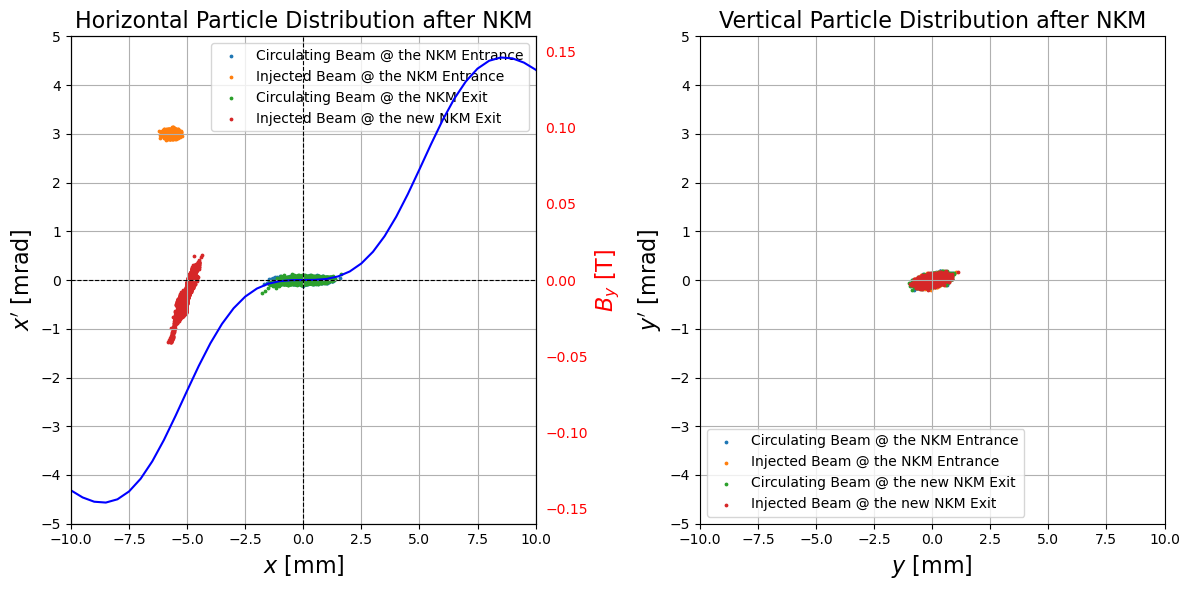

In [53]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs = axs.flatten()
tick_locator1 = MultipleLocator(2.5)
tick_locator2 = MultipleLocator(1)

axs[0].set_title('Horizontal Particle Distribution after NKM', fontsize=16)

#axs[0].scatter(init_beam_circulating[0,:]*1e3, init_beam_circulating[1,:]*1e3, s=3, label='Circulating Beam @ the NKM Entrance')
#axs[0].scatter(init_beam_circulating2[0,:]*1e3, init_beam_circulating2[1,:]*1e3, s=3, label='Circulating Beam @ the NKM Entrance')
axs[0].scatter(init_beam_circulating3[0,:]*1e3, init_beam_circulating3[1,:]*1e3, s=3, label='Circulating Beam @ the NKM Entrance')

#axs[0].scatter(new_final_beam[0,:]*1e3, new_final_beam[1,:]*1e3, s=3, label='Injected Beam @ the NKM Entrance')
#axs[0].scatter(new_final_beam2[0,:]*1e3, new_final_beam2[1,:]*1e3, s=3, label='Injected Beam @ the NKM Entrance')
axs[0].scatter(new_final_beam3[0,:]*1e3, new_final_beam3[1,:]*1e3, s=3, label='Injected Beam @ the NKM Entrance')

#axs[0].scatter(nkm_exit_beam_circulating[0,:]*1e3, nkm_exit_beam_circulating[1,:]*1e3, s=3, label='Circulating Beam @ the NKM Exit')
#axs[0].scatter(nkm_exit_beam_circulating2[0,:]*1e3, nkm_exit_beam_circulating2[1,:]*1e3, s=3, label='Circulating Beam @ the new NKM Exit')
axs[0].scatter(nkm_exit_beam_circulating3[0,:]*1e3, nkm_exit_beam_circulating3[1,:]*1e3, s=3, label='Circulating Beam @ the NKM Exit')

#axs[0].scatter(nkm_exit_beam[0,:]*1e3, nkm_exit_beam[1,:]*1e3, s=3, label='Injected Beam @ the NKM Exit')
#axs[0].scatter(nkm_exit_beam2[0,:]*1e3, nkm_exit_beam2[1,:]*1e3, s=3, label='Injected Beam @ the new NKM Exit')
axs[0].scatter(nkm_exit_beam3[0,:]*1e3, nkm_exit_beam3[1,:]*1e3, s=3, label='Injected Beam @ the new NKM Exit')

axs[0].set_xlabel(r'$x$ [mm]', fontsize=16)
axs[0].set_ylabel(r'$x^{\prime}$ [mrad]', fontsize=16)
axs[0].set_xlim([-10, 10])
axs[0].set_ylim([-5, 5])
axs[0].xaxis.set_major_locator(tick_locator1)
axs[0].yaxis.set_major_locator(tick_locator2)
axs[0].grid()
axs[0].legend(loc='best')

ax1 = axs[0].twinx()
ax1.plot(data2['x']*1e3, data2['By'], color='b', label='NKM Magnetic Field from Radia')
ax1.set_xlabel(r'$x$ [mm]', fontsize=16)
ax1.set_ylabel(r'$B_y$ [T]', fontsize=16, color='r')
ax1.set_ylim([-0.16, 0.16])
ax1.tick_params(axis='y', labelcolor='r')
ax1.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
#ax1.grid(True)
ax1.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=True)


axs[1].set_title('Vertical Particle Distribution after NKM', fontsize=16)

#axs[1].scatter(init_beam_circulating[2,:]*1e3, init_beam_circulating[3,:]*1e3, s=3, label='Circulating Beam @ the NKM Entrance')
#axs[1].scatter(init_beam_circulating2[2,:]*1e3, init_beam_circulating2[3,:]*1e3, s=3, label='Circulating Beam @ the NKM Entrance')
axs[1].scatter(init_beam_circulating3[2,:]*1e3, init_beam_circulating3[3,:]*1e3, s=3, label='Circulating Beam @ the NKM Entrance')

#axs[1].scatter(new_final_beam[2,:]*1e3, new_final_beam[3,:]*1e3, s=3, label='Injected Beam @ the NKM Entrance')
#axs[1].scatter(new_final_beam2[2,:]*1e3, new_final_beam2[3,:]*1e3, s=3, label='Injected Beam @ the NKM Entrance')
axs[1].scatter(new_final_beam3[2,:]*1e3, new_final_beam3[3,:]*1e3, s=3, label='Injected Beam @ the NKM Entrance')

#axs[1].scatter(nkm_exit_beam_circulating[2,:]*1e3, nkm_exit_beam_circulating[3,:]*1e3, s=3, label='Circulating Beam @ the NKM Exit')
#axs[1].scatter(nkm_exit_beam_circulating2[2,:]*1e3, nkm_exit_beam_circulating2[3,:]*1e3, s=3, label='Circulating Beam @ the new NKM Exit')
axs[1].scatter(nkm_exit_beam_circulating3[2,:]*1e3, nkm_exit_beam_circulating3[3,:]*1e3, s=3, label='Circulating Beam @ the new NKM Exit')

#axs[1].scatter(nkm_exit_beam[2,:]*1e3, nkm_exit_beam[3,:]*1e3, s=3, label='Injected Beam @ the NKM Exit')
#axs[1].scatter(nkm_exit_beam2[2,:]*1e3, nkm_exit_beam2[3,:]*1e3, s=3, label='Injected Beam @ the new NKM Exit')
axs[1].scatter(nkm_exit_beam3[2,:]*1e3, nkm_exit_beam3[3,:]*1e3, s=3, label='Injected Beam @ the new NKM Exit')

axs[1].set_xlabel(r'$y$ [mm]', fontsize=16)
axs[1].set_ylabel(r'$y^{\prime}$ [mrad]', fontsize=16)
axs[1].set_xlim([-10, 10])
axs[1].set_ylim([-5, 5])
axs[1].xaxis.set_major_locator(tick_locator1)
axs[1].yaxis.set_major_locator(tick_locator2)
axs[1].grid()
axs[1].legend(loc=3)

plt.tight_layout()
fig.savefig('img/beam_distributions_through_nkm.png', dpi=fig.dpi)

In [54]:
init_beam_circulating4 = init_beam_circulating.copy()
new_final_beam4 = new_final_beam.copy()

#new_final_beam4 = init_beam_circulating.copy()
#new_final_beam4[0,:] -= 6.4e-3
#new_final_beam4[1,:] += 4.0e-3

#new_final_beam4[0,:] = init_beam_circulating4[0,:]
#new_final_beam4[1,:] = init_beam_circulating4[1,:]
#new_final_beam4[2,:] = init_beam_circulating4[2,:]
#new_final_beam4[3,:] = init_beam_circulating4[3,:]
#new_final_beam4[4,:] = init_beam_circulating4[4,:]
#new_final_beam4[5,:] = init_beam_circulating4[5,:]

nkm_exit_beam_circulating4 = NKM2.track(init_beam_circulating4)
nkm_exit_beam4 = NKM2.track(new_final_beam4)

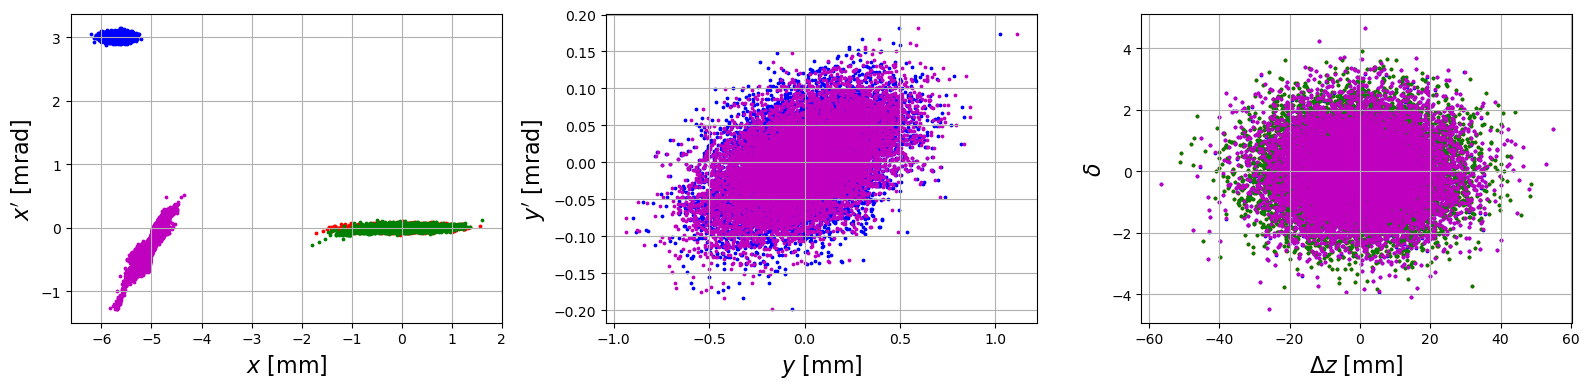

In [55]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
axs = axs.flatten()
tick_locator1 = MultipleLocator(2.5)
tick_locator2 = MultipleLocator(1)

axs[0].scatter(init_beam_circulating4[0,:]*1e3, init_beam_circulating4[1,:]*1e3, c='r', s=3, label='Circulating Beam @ the NKM Entrance')
axs[0].scatter(new_final_beam4[0,:]*1e3, new_final_beam4[1,:]*1e3, c='b', s=3, label='Injected Beam @ the NKM Entrance')

axs[0].scatter(nkm_exit_beam_circulating4[0,:]*1e3, nkm_exit_beam_circulating4[1,:]*1e3, c='g', s=3, label='Circulating Beam @ the new NKM Exit')
axs[0].scatter(nkm_exit_beam4[0,:]*1e3, nkm_exit_beam4[1,:]*1e3, c='m', s=3, label='Injected Beam @ the new NKM Exit')

axs[0].set_xlabel(r'$x$ [mm]', fontsize=16)
axs[0].set_ylabel(r'$x^{\prime}$ [mrad]', fontsize=16)
#axs[0].set_xlim([-12, 12])
#axs[0].set_ylim([-20, 20])
#axs[0].legend(loc='best')
axs[0].grid()

#axs[1].scatter(init_beam_circulating4[2,:]*1e3, init_beam_circulating4[3,:]*1e3, c='r', s=3, label='Circulating Beam @ the NKM Entrance')
axs[1].scatter(new_final_beam4[2,:]*1e3, new_final_beam4[3,:]*1e3, c='b', s=3, label='Injected Beam @ the NKM Entrance')

#axs[1].scatter(nkm_exit_beam_circulating4[2,:]*1e3, nkm_exit_beam_circulating4[3,:]*1e3, c='g', s=3, label='Circulating Beam @ the new NKM Exit')
axs[1].scatter(nkm_exit_beam4[2,:]*1e3, nkm_exit_beam4[3,:]*1e3, c='m', s=3, label='Injected Beam @ the new NKM Exit')

axs[1].set_xlabel(r'$y$ [mm]', fontsize=16)
axs[1].set_ylabel(r'$y^{\prime}$ [mrad]', fontsize=16)
#axs[1].set_xlim([-10, 10])
#axs[1].set_ylim([-5, 5])
#axs[1].legend(loc='best')
axs[1].grid()

axs[2].scatter(init_beam_circulating4[5,:]*1e3, init_beam_circulating4[4,:]*1e3, c='r', s=3, label='Circulating Beam @ the NKM Entrance')
axs[2].scatter(new_final_beam4[5,:]*1e3, new_final_beam4[4,:]*1e3, c='b', s=3, label='Injected Beam @ the NKM Entrance')

axs[2].scatter(nkm_exit_beam_circulating4[5,:]*1e3, nkm_exit_beam_circulating4[4,:]*1e3, c='g', s=3, label='Circulating Beam @ the new NKM Exit')
axs[2].scatter(nkm_exit_beam4[5,:]*1e3, nkm_exit_beam4[4,:]*1e3, c='m', s=3, label='Injected Beam @ the new NKM Exit')

axs[2].set_xlabel(r'$\Delta z$ [mm]', fontsize=16)
axs[2].set_ylabel(r'$\delta$', fontsize=16)
#axs[2].set_xlim([-10, 10])
#axs[2].set_ylim([-5, 5])
#axs[2].legend(loc='best')
axs[2].grid()

plt.tight_layout()

In [56]:
x_diff  = new_final_beam[0,:] - nkm_exit_beam[0,:]
xp_diff = new_final_beam[1,:] - nkm_exit_beam[1,:]

x_diff2  = new_final_beam[0,:] - nkm_exit_beam2[0,:]
xp_diff2 = new_final_beam[1,:] - nkm_exit_beam2[1,:]

In [ ]:
# Plot the difference in x-x' plane
plt.figure(figsize=(10, 6))
plt.scatter(x_diff*1e3, xp_diff*1e3, s=3, alpha=0.5)
plt.scatter(x_diff2*1e3, xp_diff2*1e3, s=3, alpha=0.5)
plt.xlabel(r'$\Delta x$ [mm]', fontsize=16)
plt.ylabel(r'$\Delta x^{\prime}$ [mrad]', fontsize=16)
plt.title('Coordinates Changes after Passing through NKM', fontsize=16)
plt.grid(True)
plt.show()

## Injected Beam Tracking in the Storage Ring Lattice

### Load Storage Ring Lattice and Extract Lattice Functions at the injection point

In [1]:
# load original storage ring lattice
original_storage_ring_lattice = at.load_mat('K4GSR_HBIv4-1.mat')

# remove the first drift element from the storage ring lattice to add NKM
section_start = original_storage_ring_lattice[0]
section_end = original_storage_ring_lattice[-1]
len(original_storage_ring_lattice)
# This removes the first drift element and first and last markers
storage_ring_lattice_after_nkm = original_storage_ring_lattice[2:len(original_storage_ring_lattice)-1]

# Define a new drift element to add at the end of the lattice
dr_nkm_up = at.Drift('NKMUP', 1.875)  # a drift element upstream of nkm
dr_nkm = at.Drift('NKM', 0.525)  # NKM element
dr_nkm_down = at.Drift('NKMDOWN', 0.3)  # a drift element downstream of nkm

# append the drift elements to the end of the modified storage ring lattice
storage_ring_lattice_after_nkm.append(dr_nkm_up)
storage_ring_lattice_after_nkm.append(dr_nkm)
storage_ring_lattice_after_nkm.append(section_end)

# insert drift elements to the begiining of modified storage ring lattice
storage_ring_lattice_after_nkm.insert(0, dr_nkm_down)
storage_ring_lattice_after_nkm.insert(0, section_start)
                            
# Optionally, save the modified lattice to a file for future use
at.save_mat(storage_ring_lattice_after_nkm, 'storage_ring_lattice_after_nkm.mat')

NameError: name 'at' is not defined

In [59]:
try:
    twiss_params = storage_ring_lattice_after_nkm.get_optics()
    print("Twiss Parameters recalculated successfully.")
except Exception as e:
    print("Error recalculating Twiss parameters:", e)

Twiss Parameters recalculated successfully.


In [60]:
# Check new storage ring lattice
index = 0
print (index, storage_ring_lattice_after_nkm[0])
for elem in storage_ring_lattice_after_nkm:
    if elem.FamName == 'NKMUP' or elem.FamName == 'NKM' or elem.FamName == 'NKMDOWN':
        print(index, elem)
    #print(index, elem.FamName)
    index += 1
print (index, storage_ring_lattice_after_nkm[-1])
print ("total numbers of lattice elements:", len(original_storage_ring_lattice), len(storage_ring_lattice))

# Calculate the total circumference by summing up the lengths of all elements
total_circumference_orig = sum(element.Length for element in original_storage_ring_lattice if hasattr(element, 'Length'))
total_circumference = sum(element.Length for element in storage_ring_lattice_after_nkm if hasattr(element, 'Length'))

# Print the total circumference
print(f'Total circumference of the original storage ring: {total_circumference_orig:.3f} meters')
print(f'Total circumference of the storage ring: {total_circumference:.3f} meters')

0 Marker:
       FamName: SectionStart
        Length: 0.0
    PassMethod: IdentityPass
1 Drift:
       FamName: NKMDOWN
        Length: 0.3
    PassMethod: DriftPass
3480 Drift:
       FamName: NKMUP
        Length: 1.875
    PassMethod: DriftPass
3481 Drift:
       FamName: NKM
        Length: 0.525
    PassMethod: DriftPass
3483 Marker:
       FamName: SectionEnd
        Length: 0.0
    PassMethod: IdentityPass
total numbers of lattice elements: 3481 3483
Total circumference of the original storage ring: 799.297 meters
Total circumference of the storage ring: 799.297 meters


### Beam Tracking in Storage Ring

In [61]:
def track_ring(beam_distribution):
    # track through the storage ring after the nkm element
    track2 = at.lattice_track(storage_ring_lattice_after_nkm, beam_distribution, 2)[1]['rout']

    # create a negative length drift element for backtracking
    backtrack_dr_nkm = at.Drift('NKM_BACK', -0.525)  # Drift with negative length for backtracking

    # propagate the particles through the negative length drift (backtracking) for the nkm element
    track3 = at.element_track(backtrack_dr_nkm, track2)
    
    # propagte the particles through the nkm element
    #track4 = nkm_tracking(track3)
    track4 = NKM2.track(track3)

    return(track2, track3, track4)

In [62]:
# copy the injected beam distribution after the nkm element
track1_particles = nkm_exit_beam.copy()
track2_particles, track3_particles, track4_particles = track_ring(track1_particles)

In [63]:
print(track1_particles[:,0])
print(track1_particles[:,1])
for i in range(0, 3):
    print(at.lattice_track(original_storage_ring_lattice, track1_particles[:,i], 1)[1]['rout'])
print(track2_particles[:,0])
print(track2_particles[:,2])

[-5.21379145e-03 -4.22572453e-04  2.10684686e-04 -8.00137874e-05
 -1.30397161e-03 -4.35009604e-03]
[-5.14591021e-03 -3.13755079e-04  2.91195543e-04  6.97281779e-05
  5.34335412e-06  8.31432214e-04]
[-7.52496858e-03  1.76102368e-04 -4.32051523e-04 -4.14036822e-06
 -1.27674096e-03 -4.35764864e-03]
[-6.38910465e-03  1.71941166e-04  2.83188299e-04 -7.19482373e-05
 -4.48936125e-06  8.62307954e-04]
[-7.08403720e-03  9.05939093e-05  1.14620042e-04  4.62725898e-05
  2.67639816e-03  3.15058716e-03]
[-0.0003262   0.00048776  0.00027625  0.00011516 -0.00124752 -0.00443485]
[-1.94284036e-03  3.87196183e-04  2.67727184e-04 -1.28524053e-05
  2.64849227e-03  3.30330275e-03]


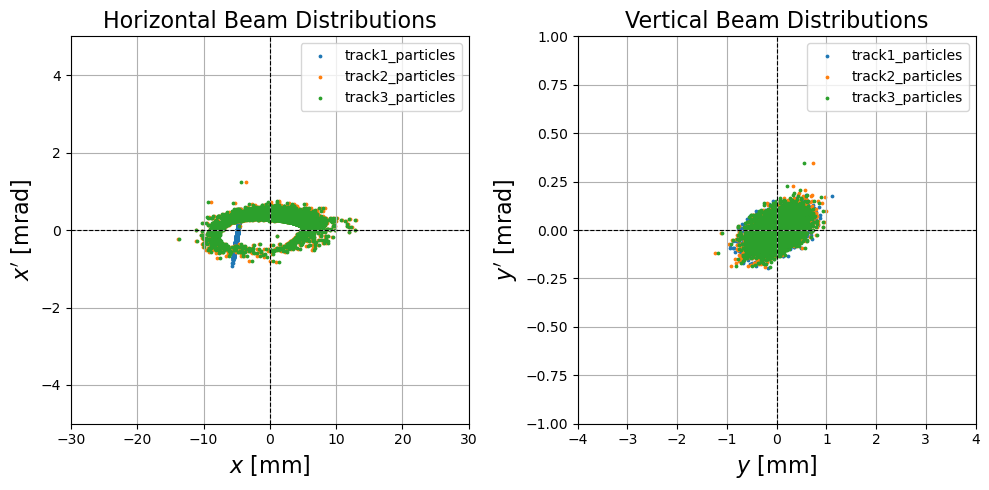

In [64]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs = axs.flatten()

axs[0].set_title('Horizontal Beam Distributions', fontsize=16)
axs[0].scatter(track1_particles[0,:]*1e3, track1_particles[1,:]*1e3, s=3, label='track1_particles')
axs[0].scatter(track2_particles[0,:]*1e3, track2_particles[1,:]*1e3, s=3, label='track2_particles')
axs[0].scatter(track3_particles[0,:]*1e3, track3_particles[1,:]*1e3, s=3, label='track3_particles')
#axs[0].scatter(track4_particles[0,:]*1e3, track4_particles[1,:]*1e3, s=3, label='track4_particles')
axs[0].set_xlabel(r'$x$ [mm]', fontsize=16)
axs[0].set_ylabel(r'$x^{\prime}$ [mrad]', fontsize=16)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference)
axs[0].set_xlim([-30, 30])
axs[0].set_ylim([-5, 5])
axs[0].grid()
axs[0].legend(loc='best')

axs[1].set_title('Vertical Beam Distributions', fontsize=16)
axs[1].scatter(track1_particles[2,:]*1e3, track1_particles[3,:]*1e3, s=3, label='track1_particles')
axs[1].scatter(track2_particles[2,:]*1e3, track2_particles[3,:]*1e3, s=3, label='track2_particles')
axs[1].scatter(track3_particles[2,:]*1e3, track3_particles[3,:]*1e3, s=3, label='track3_particles')
#axs[1].scatter(track4_particles[2,:]*1e3, track4_particles[3,:]*1e3, s=3, label='track4_particles')
axs[1].set_xlabel(r'$y$ [mm]', fontsize=16)
axs[1].set_ylabel(r'$y^{\prime}$ [mrad]', fontsize=16)
axs[1].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
axs[1].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
axs[1].set_xlim([-4, 4])
axs[1].set_ylim([-1, 1])
axs[1].grid()
axs[1].legend(loc='best')

plt.tight_layout()

### Multi-Turn Tracking for Injected Beam

Turn 1: Total     2/10000 particles are losted
Turn 2: Total    10/10000 particles are losted
Turn 3: Total    19/10000 particles are losted
Turn 4: Total    30/10000 particles are losted
Turn 5: Total    41/10000 particles are losted
Turn 6: Total    52/10000 particles are losted
Turn 7: Total    63/10000 particles are losted
Turn 8: Total    74/10000 particles are losted
Turn 9: Total    85/10000 particles are losted
Turn 10: Total    96/10000 particles are losted
Turn 11: Total   107/10000 particles are losted
Turn 12: Total   118/10000 particles are losted
Turn 13: Total   129/10000 particles are losted
Turn 14: Total   140/10000 particles are losted
Turn 15: Total   151/10000 particles are losted
Turn 16: Total   162/10000 particles are losted
Turn 17: Total   173/10000 particles are losted
Turn 18: Total   184/10000 particles are losted
Turn 19: Total   195/10000 particles are losted
Turn 20: Total   206/10000 particles are losted


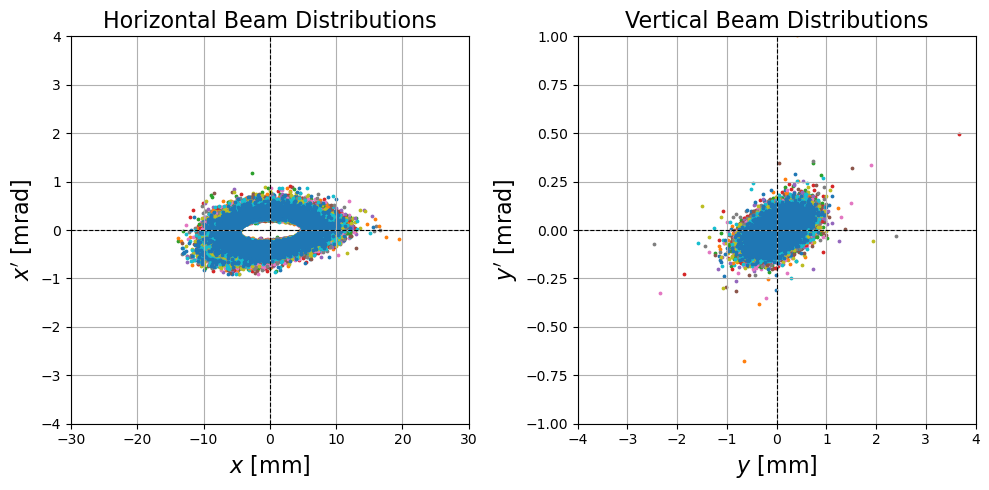

In [65]:
nturns = 20
num_lost_particles = 0

injected_beam = nkm_exit_beam.copy()
#injected_beam[0,:] -= 0.0027
#injected_beam[0,:] *= 0.1
#injected_beam[1,:] *= 0.1
nparticles = injected_beam.shape[1]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs = axs.flatten()

axs[0].scatter(injected_beam[0,:]*1e3, injected_beam[1,:]*1e3, s=3, label='turn 0')
axs[1].scatter(injected_beam[2,:]*1e3, injected_beam[3,:]*1e3, s=3, label='turn 0')

# initial particle distributions
track_particles = injected_beam.copy()
# enable radiation damping
storage_ring_lattice_after_nkm_and_radiation_on = storage_ring_lattice_after_nkm.enable_6d(at.Radiative, copy=True)

for turn in range(nturns):
    track_particles = at.lattice_track(storage_ring_lattice_after_nkm_and_radiation_on, track_particles, 1)[1]['rout']
    axs[0].scatter(track_particles[0,:]*1e3, track_particles[1,:]*1e3, s=3, label=('turn %d' % (turn+1)))
    axs[1].scatter(track_particles[2,:]*1e3, track_particles[3,:]*1e3, s=3, label=('turn %d' % (turn+1)))
    lost_particles_mask = np.isnan(track_particles).any(axis=0)
    num_lost_particles += np.sum(lost_particles_mask)
    print("Turn %d: Total %5d/%d particles are losted" % (turn+1, num_lost_particles, nparticles))

axs[0].set_title('Horizontal Beam Distributions', fontsize=16)
axs[0].set_xlabel(r'$x$ [mm]', fontsize=16)
axs[0].set_ylabel(r'$x^{\prime}$ [mrad]', fontsize=16)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
axs[0].set_xlim([-30, 30])
axs[0].set_ylim([-4, 4])
axs[0].grid()
#axs[0].legend(loc='best')

axs[1].set_title('Vertical Beam Distributions', fontsize=16)

axs[1].set_xlabel(r'$y$ [mm]', fontsize=16)
axs[1].set_ylabel(r'$y^{\prime}$ [mrad]', fontsize=16)
axs[1].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
axs[1].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
axs[1].set_xlim([-4, 4])
axs[1].set_ylim([-1, 1])
axs[1].grid()
#axs[1].legend(loc='best')

plt.tight_layout()
fig.savefig('img/beam_distributions_through_ring_injected.png', dpi=fig.dpi)

Turn 1: Total     2/10000 particles are losted
Turn 2: Total    10/10000 particles are losted
Turn 3: Total    19/10000 particles are losted
Turn 4: Total    30/10000 particles are losted
Turn 5: Total    41/10000 particles are losted
Turn 6: Total    52/10000 particles are losted
Turn 7: Total    63/10000 particles are losted
Turn 8: Total    74/10000 particles are losted
Turn 9: Total    85/10000 particles are losted


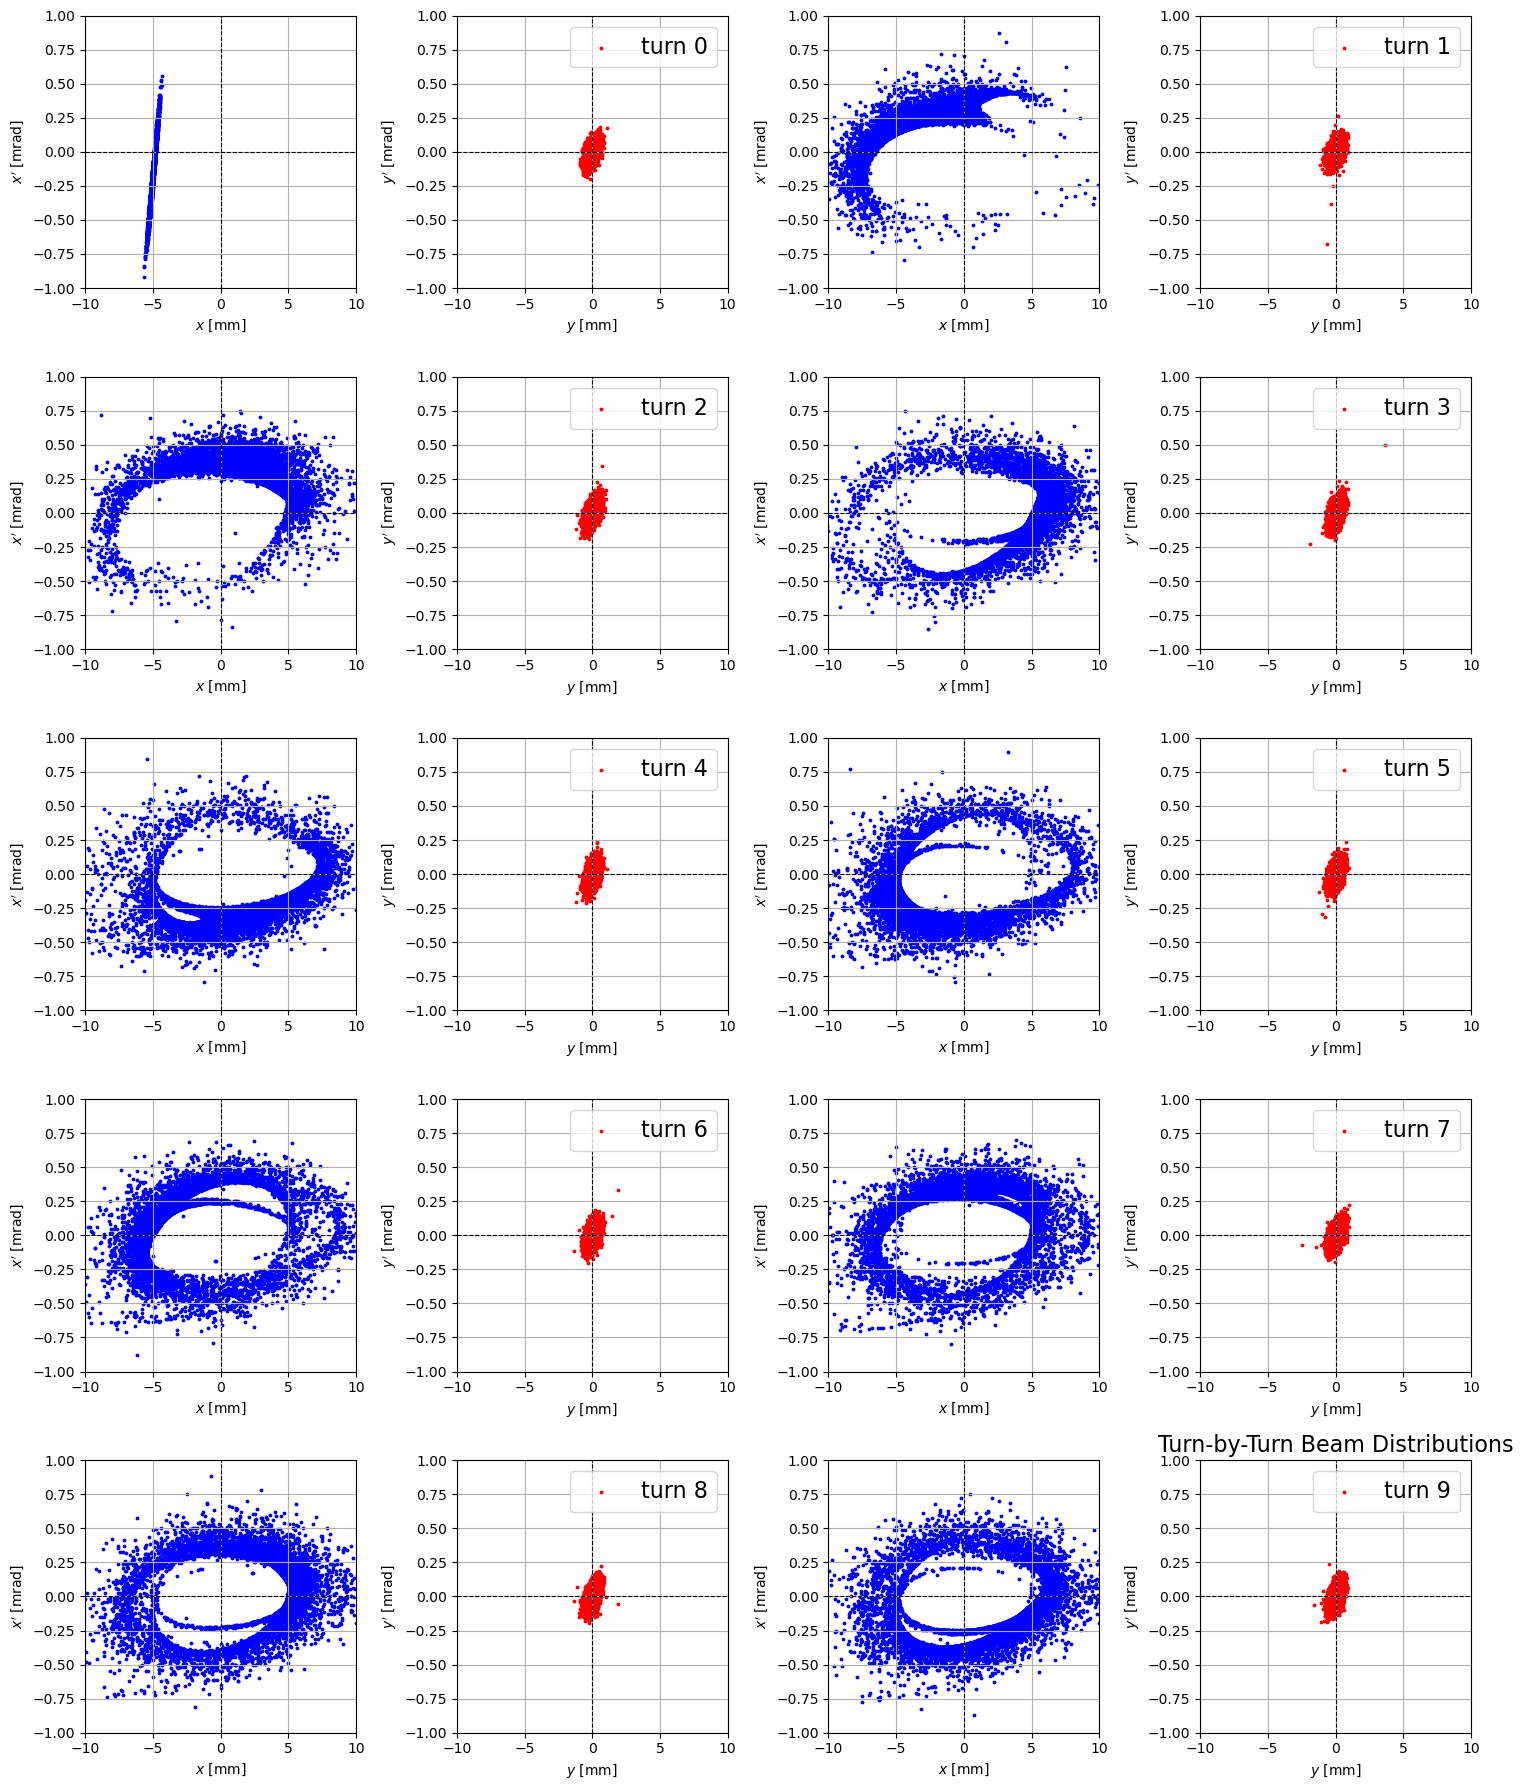

In [66]:
nturns = 9
if nturns % 2 == 0:
    print ("nturns should be an odd number")
    nturns += 1
    print ("new nturns are", nturns)
row = int((nturns+1)/2)
col_size = int(nturns*2)
num_lost_particles = 0

injected_beam = nkm_exit_beam.copy()
nparticles = injected_beam.shape[1]

fig, axs = plt.subplots(row, 4, figsize=(15,col_size))
plt.title('Turn-by-Turn Beam Distributions', fontsize=16)
axs = axs.flatten()

axs[0].scatter(injected_beam[0,:]*1e3, injected_beam[1,:]*1e3, s=3, label='turn 0', c='b')
axs[0].set_xlabel(r'$x$ [mm]', fontsize=10)
axs[0].set_ylabel(r'$x^{\prime}$ [mrad]', fontsize=10)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
axs[0].set_xlim([-10, 10])
axs[0].set_ylim([-1, 1])
axs[0].grid()

axs[1].scatter(injected_beam[2,:]*1e3, injected_beam[3,:]*1e3, s=3, label='turn 0', c='r')
axs[1].set_xlabel(r'$y$ [mm]', fontsize=10)
axs[1].set_ylabel(r'$y^{\prime}$ [mrad]', fontsize=10)
axs[1].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
axs[1].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
axs[1].set_xlim([-10, 10])
axs[1].set_ylim([-1, 1])
axs[1].grid()
axs[1].legend(loc=1, fontsize=16)


# initial particle distributions
track_particles = injected_beam.copy()
# enable radiation damping
storage_ring_lattice_after_nkm_and_radiation_on = storage_ring_lattice_after_nkm.enable_6d(at.Radiative, copy=True)

index = 2
for turn in range(nturns):
    track_particles = at.lattice_track(storage_ring_lattice_after_nkm_and_radiation_on, track_particles, 1)[1]['rout']
    axs[index].scatter(track_particles[0,:]*1e3, track_particles[1,:]*1e3, s=3, label=('turn %d' % (turn+1)), c='b')
    axs[index].set_xlabel(r'$x$ [mm]', fontsize=10)
    axs[index].set_ylabel(r'$x^{\prime}$ [mrad]', fontsize=10)
    axs[index].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
    axs[index].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
    axs[index].set_xlim([-10, 10])
    axs[index].set_ylim([-1, 1])
    axs[index].grid()
    #axs[index].legend(loc=3)
    
    axs[index+1].scatter(track_particles[2,:]*1e3, track_particles[3,:]*1e3, s=3, label=('turn %d' % (turn+1)), c='r')
    axs[index+1].set_xlabel(r'$y$ [mm]', fontsize=10)
    axs[index+1].set_ylabel(r'$y^{\prime}$ [mrad]', fontsize=10)
    axs[index+1].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
    axs[index+1].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
    axs[index+1].set_xlim([-10, 10])
    axs[index+1].set_ylim([-1, 1])
    axs[index+1].grid()
    axs[index+1].legend(loc=1, fontsize=16)

    lost_particles_mask = np.isnan(track_particles).any(axis=0)
    num_lost_particles += np.sum(lost_particles_mask)
    print("Turn %d: Total %5d/%d particles are losted" % (turn+1, num_lost_particles, nparticles))

    index += 2

plt.tight_layout()
fig.savefig('img/beam_distributions_through_ring_injected_tbt.png', dpi=fig.dpi)

### Multi-Turn Tracking for Circulating Beam

Turn 1: Total     0/10000 particles are losted
Turn 2: Total     0/10000 particles are losted
Turn 3: Total     0/10000 particles are losted
Turn 4: Total     0/10000 particles are losted
Turn 5: Total     0/10000 particles are losted
Turn 6: Total     0/10000 particles are losted
Turn 7: Total     0/10000 particles are losted
Turn 8: Total     0/10000 particles are losted
Turn 9: Total     0/10000 particles are losted
Turn 10: Total     0/10000 particles are losted
Turn 11: Total     0/10000 particles are losted
Turn 12: Total     0/10000 particles are losted
Turn 13: Total     0/10000 particles are losted
Turn 14: Total     0/10000 particles are losted
Turn 15: Total     0/10000 particles are losted
Turn 16: Total     0/10000 particles are losted
Turn 17: Total     0/10000 particles are losted
Turn 18: Total     0/10000 particles are losted
Turn 19: Total     0/10000 particles are losted
Turn 20: Total     0/10000 particles are losted


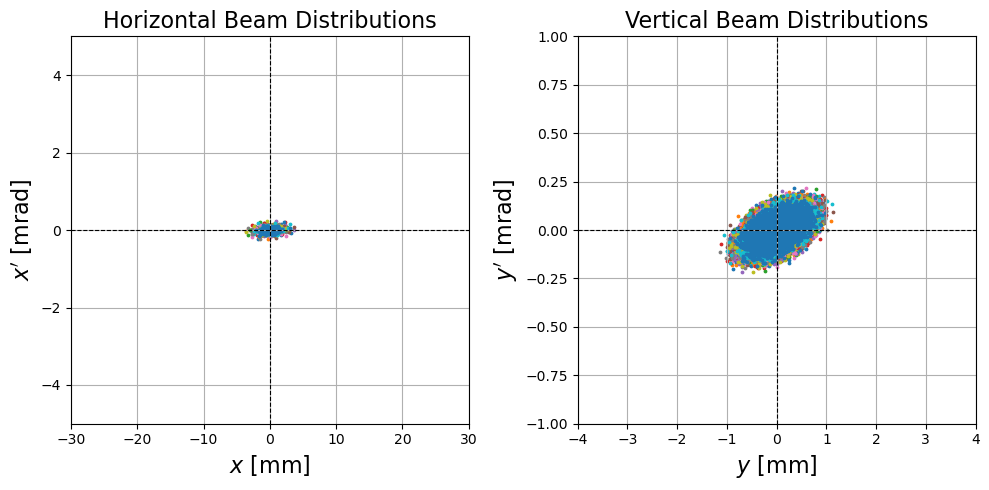

In [67]:
nturns = 20
num_lost_particles = 0

injected_beam = nkm_exit_beam_circulating.copy()
nparticles = injected_beam.shape[1]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs = axs.flatten()

axs[0].scatter(injected_beam[0,:]*1e3, injected_beam[1,:]*1e3, s=3, label='turn 0')
axs[1].scatter(injected_beam[2,:]*1e3, injected_beam[3,:]*1e3, s=3, label='turn 0')

track_particles = injected_beam.copy()
for turn in range(nturns):
    track_particles = at.lattice_track(storage_ring_lattice_after_nkm, track_particles, 1)[1]['rout']
    axs[0].scatter(track_particles[0,:]*1e3, track_particles[1,:]*1e3, s=3, label=('turn %d' % (turn+1)))
    axs[1].scatter(track_particles[2,:]*1e3, track_particles[3,:]*1e3, s=3, label=('turn %d' % (turn+1)))
    lost_particles_mask = np.isnan(track_particles).any(axis=0)
    num_lost_particles += np.sum(lost_particles_mask)
    print("Turn %d: Total %5d/%d particles are losted" % (turn+1, num_lost_particles, nparticles))

axs[0].set_title('Horizontal Beam Distributions', fontsize=16)
axs[0].set_xlabel(r'$x$ [mm]', fontsize=16)
axs[0].set_ylabel(r'$x^{\prime}$ [mrad]', fontsize=16)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
axs[0].set_xlim([-30, 30])
axs[0].set_ylim([-5, 5])
axs[0].grid()
#axs[0].legend(loc='best')

axs[1].set_title('Vertical Beam Distributions', fontsize=16)

axs[1].set_xlabel(r'$y$ [mm]', fontsize=16)
axs[1].set_ylabel(r'$y^{\prime}$ [mrad]', fontsize=16)
axs[1].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
axs[1].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
axs[1].set_xlim([-4, 4])
axs[1].set_ylim([-1, 1])
axs[1].grid()
#axs[1].legend(loc='best')

plt.tight_layout()
fig.savefig('img/beam_distributions_through_ring_circulating.png', dpi=fig.dpi)

Turn 1: Total     0/10000 particles are losted
Turn 2: Total     0/10000 particles are losted
Turn 3: Total     0/10000 particles are losted
Turn 4: Total     0/10000 particles are losted
Turn 5: Total     0/10000 particles are losted
Turn 6: Total     0/10000 particles are losted
Turn 7: Total     0/10000 particles are losted
Turn 8: Total     0/10000 particles are losted
Turn 9: Total     0/10000 particles are losted


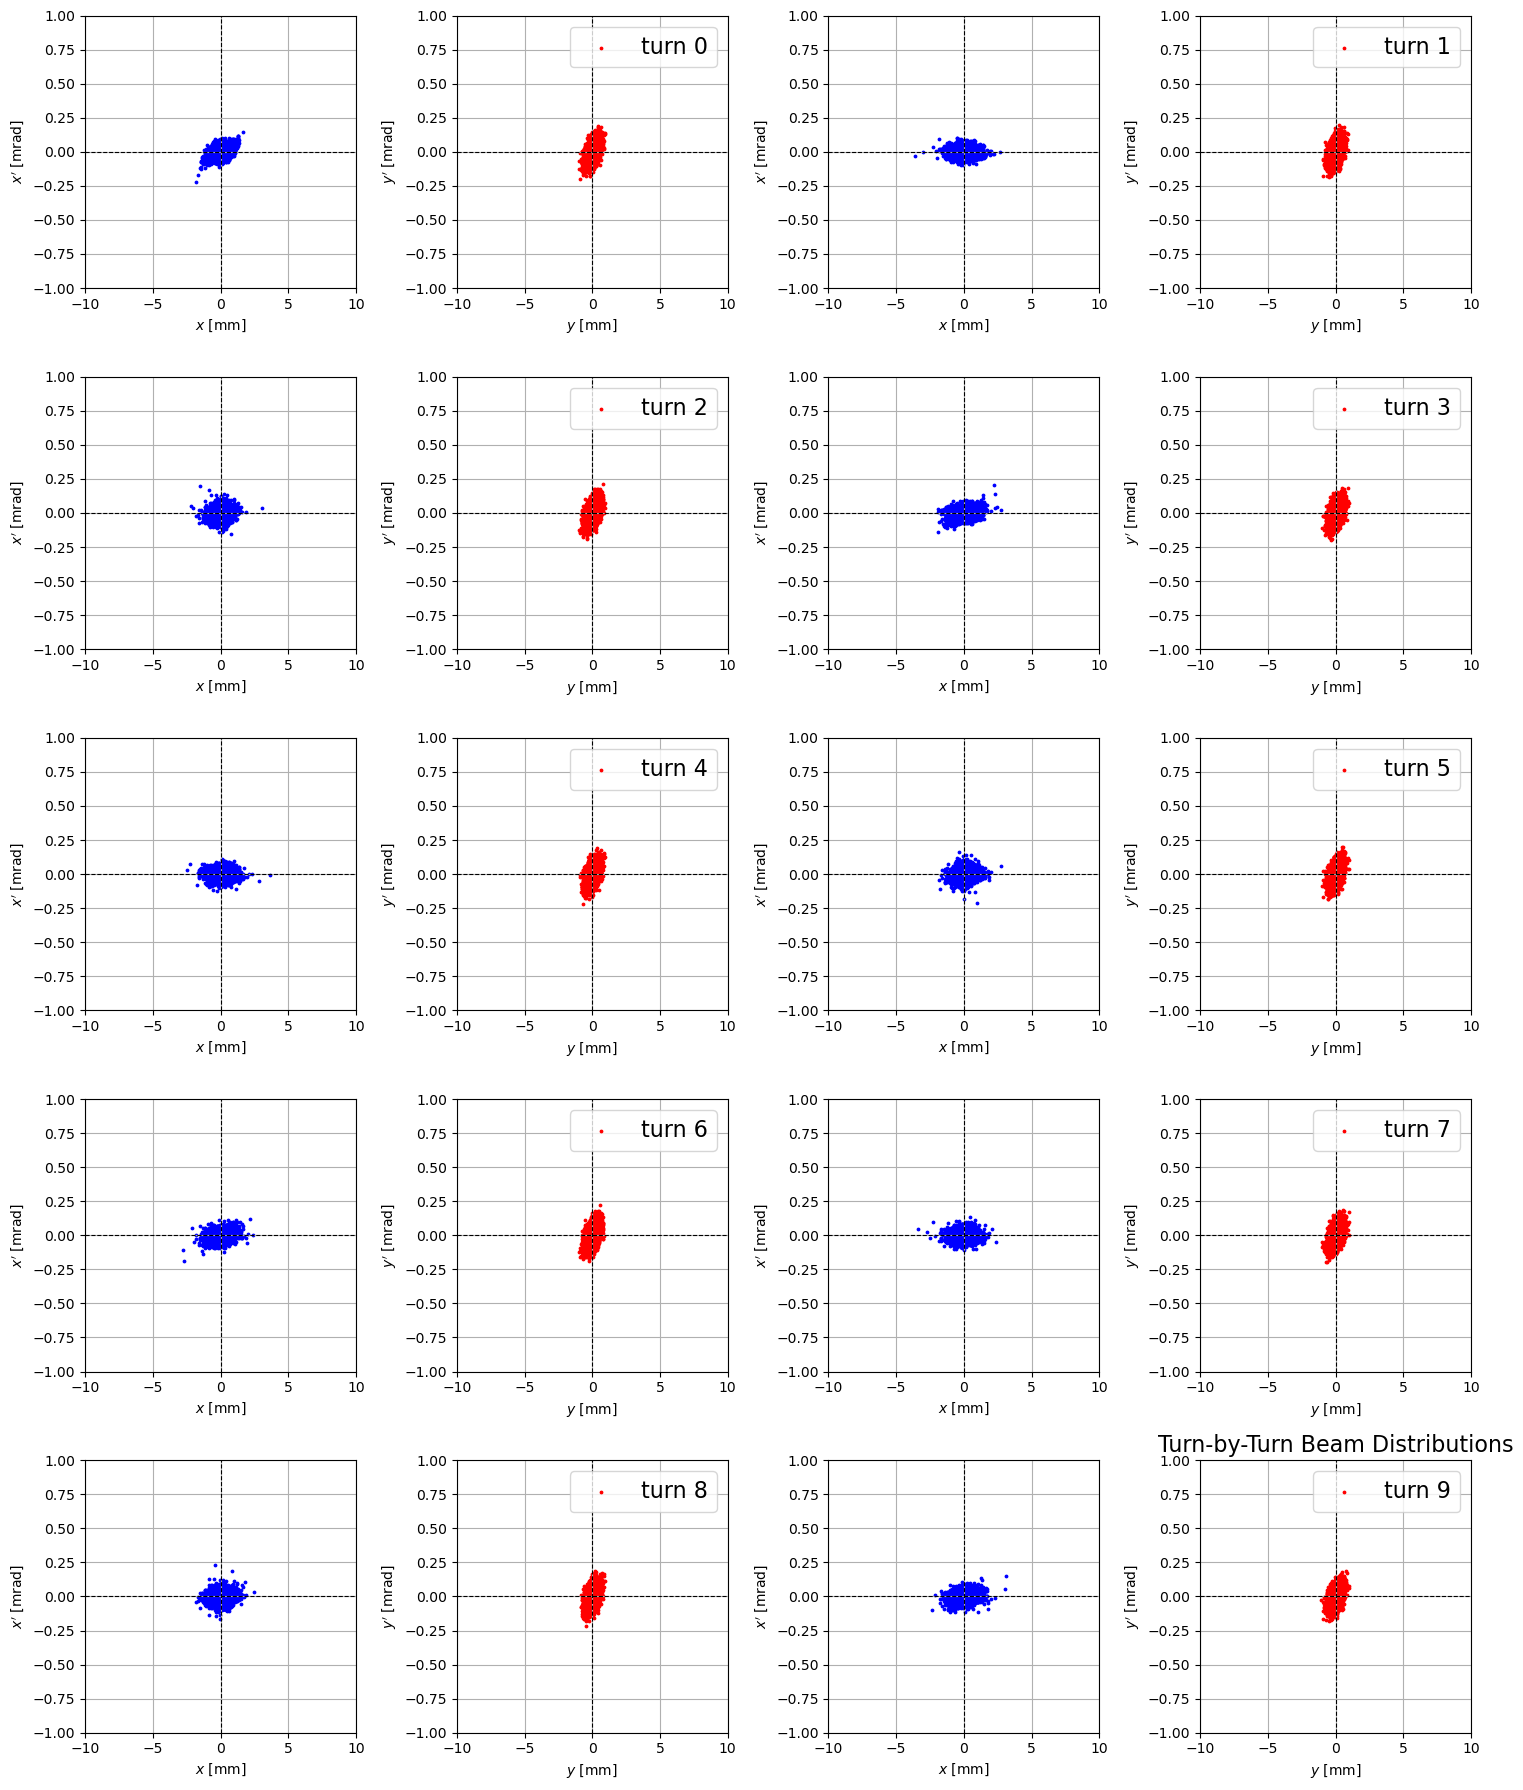

In [68]:
nturns = 9
if nturns % 2 == 0:
    print ("nturns should be an odd number")
    nturns += 1
    print ("new nturns are", nturns)
row = int((nturns+1)/2)
col_size = int(nturns*2)
num_lost_particles = 0

injected_beam = nkm_exit_beam_circulating.copy()
nparticles = injected_beam.shape[1]

fig, axs = plt.subplots(row, 4, figsize=(15,col_size))
plt.title('Turn-by-Turn Beam Distributions', fontsize=16)
axs = axs.flatten()

axs[0].scatter(injected_beam[0,:]*1e3, injected_beam[1,:]*1e3, s=3, label='turn 0', c='b')
axs[0].set_xlabel(r'$x$ [mm]', fontsize=10)
axs[0].set_ylabel(r'$x^{\prime}$ [mrad]', fontsize=10)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
axs[0].set_xlim([-10, 10])
axs[0].set_ylim([-1, 1])
axs[0].grid()

axs[1].scatter(injected_beam[2,:]*1e3, injected_beam[3,:]*1e3, s=3, label='turn 0', c='r')
axs[1].set_xlabel(r'$y$ [mm]', fontsize=10)
axs[1].set_ylabel(r'$y^{\prime}$ [mrad]', fontsize=10)
axs[1].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
axs[1].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
axs[1].set_xlim([-10, 10])
axs[1].set_ylim([-1, 1])
axs[1].grid()
axs[1].legend(loc=1, fontsize=16)


# initial particle distributions
track_particles = injected_beam.copy()
# enable radiation damping
storage_ring_lattice_after_nkm_and_radiation_on = storage_ring_lattice_after_nkm.enable_6d(at.Radiative, copy=True)

index = 2
for turn in range(nturns):
    track_particles = at.lattice_track(storage_ring_lattice_after_nkm_and_radiation_on, track_particles, 1)[1]['rout']
    axs[index].scatter(track_particles[0,:]*1e3, track_particles[1,:]*1e3, s=3, label=('turn %d' % (turn+1)), c='b')
    axs[index].set_xlabel(r'$x$ [mm]', fontsize=10)
    axs[index].set_ylabel(r'$x^{\prime}$ [mrad]', fontsize=10)
    axs[index].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
    axs[index].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
    axs[index].set_xlim([-10, 10])
    axs[index].set_ylim([-1, 1])
    axs[index].grid()
    #axs[index].legend(loc=3)
    
    axs[index+1].scatter(track_particles[2,:]*1e3, track_particles[3,:]*1e3, s=3, label=('turn %d' % (turn+1)), c='r')
    axs[index+1].set_xlabel(r'$y$ [mm]', fontsize=10)
    axs[index+1].set_ylabel(r'$y^{\prime}$ [mrad]', fontsize=10)
    axs[index+1].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
    axs[index+1].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
    axs[index+1].set_xlim([-10, 10])
    axs[index+1].set_ylim([-1, 1])
    axs[index+1].grid()
    axs[index+1].legend(loc=1, fontsize=16)

    lost_particles_mask = np.isnan(track_particles).any(axis=0)
    num_lost_particles += np.sum(lost_particles_mask)
    print("Turn %d: Total %5d/%d particles are losted" % (turn+1, num_lost_particles, nparticles))

    index += 2

plt.tight_layout()
fig.savefig('img/beam_distributions_through_ring_circulating_tbt.png', dpi=fig.dpi)

## Compute acceptance

In [ ]:
import os
import numpy as np

compute_acceptance = False
npy_filename = "acceptance.npy"

if compute_acceptance:
    npoints = (25, 25)          # Optimized grid resolution for fast clean execution
    amplitudes = (15e-3, 2e-3)  # Maximum amplitude in [m]
    nturns = 50                  # Number of turns for tracking to determine stability
    use_mp = False                # use_mp=True for parallelized computations
    
    # Compute the horizontal acceptance at the selected reference point
    boundary, survived, tracked = storage_ring_lattice_after_nkm.get_acceptance(
        planes=['x', 'xp'],
        npoints=npoints,
        amplitudes=amplitudes,
        nturns=nturns,
        use_mp=use_mp
    )
    np.save(npy_filename, survived)
elif os.path.exists(npy_filename):
    survived = np.load(npy_filename)
else:
    survived = np.zeros((2, 100))


In [ ]:
from scipy.spatial import ConvexHull, convex_hull_plot_2d

x_coords_survived = survived[0]
xp_coords_survived = survived[1]

plt.figure(figsize=(10, 6))
plt.scatter(x_coords_survived*1e3, xp_coords_survived*1e3, s=1, color='b', label='Survived')

# Calculate and plot the convex hull (outer boundary)
points = np.vstack((x_coords_survived, xp_coords_survived)).T  # Create a 2D array of points (x, xp)
hull = ConvexHull(points)

# Plot the convex hull by connecting the vertices
for simplex in hull.simplices:
    plt.plot(points[simplex, 0]*1e3, points[simplex, 1]*1e3, 'r-', linewidth=1.5, label='Acceptance' if simplex[0] == hull.simplices[0, 0] else "")

# Set plot labels and title
plt.xlabel('x [mm]', fontsize=14)
plt.ylabel("x' [mrad]", fontsize=14)
plt.title('Horizontal Acceptance', fontsize=16)
plt.xlim([-15,15])
plt.ylim([0,1])
plt.grid(True)
#plt.legend()

plt.savefig('img/lattice/ring_acceptance.png', dpi=fig.dpi)

## Testing Offset Beam Tracking

Track offset/shifted beam through the ring withou the nkm element.

In [ ]:
nturns = 9
if nturns % 2 == 0:
    print ("nturns should be an odd number")
    nturns += 1
    print ("new nturns are", nturns)
row = int((nturns+1)/2)
col_size = int(nturns*2)
num_lost_particles = 0

injected_beam = nkm_exit_beam_circulating.copy()
injected_beam[0,:] += -0.005
#injected_beam[1,:] += 0.001

nparticles = injected_beam.shape[1]

fig, axs = plt.subplots(row, 4, figsize=(15,col_size))
plt.title('Turn-by-Turn Beam Distributions', fontsize=16)
axs = axs.flatten()

axs[0].scatter(injected_beam[0,:]*1e3, injected_beam[1,:]*1e3, s=3, label='turn 0', c='b')
axs[0].set_xlabel(r'$x$ [mm]', fontsize=10)
axs[0].set_ylabel(r'$x^{\prime}$ [mrad]', fontsize=10)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
axs[0].set_xlim([-10, 10])
axs[0].set_ylim([-1, 1])
axs[0].grid()

axs[1].scatter(injected_beam[2,:]*1e3, injected_beam[3,:]*1e3, s=3, label='turn 0', c='r')
axs[1].set_xlabel(r'$y$ [mm]', fontsize=10)
axs[1].set_ylabel(r'$y^{\prime}$ [mrad]', fontsize=10)
axs[1].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
axs[1].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
axs[1].set_xlim([-10, 10])
axs[1].set_ylim([-1, 1])
axs[1].grid()
axs[1].legend(loc=1, fontsize=16)


# initial particle distributions
track_particles = injected_beam.copy()
# enable radiation damping
storage_ring_lattice_after_nkm_and_radiation_on = storage_ring_lattice_after_nkm.enable_6d(at.Radiative, copy=True)

index = 2
for turn in range(nturns):
    track_particles = at.lattice_track(storage_ring_lattice_after_nkm_and_radiation_on, track_particles, 1)[1]['rout']
    axs[index].scatter(track_particles[0,:]*1e3, track_particles[1,:]*1e3, s=3, label=('turn %d' % (turn+1)), c='b')
    axs[index].set_xlabel(r'$x$ [mm]', fontsize=10)
    axs[index].set_ylabel(r'$x^{\prime}$ [mrad]', fontsize=10)
    axs[index].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
    axs[index].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
    axs[index].set_xlim([-10, 10])
    axs[index].set_ylim([-1, 1])
    axs[index].grid()
    #axs[index].legend(loc=3)
    
    axs[index+1].scatter(track_particles[2,:]*1e3, track_particles[3,:]*1e3, s=3, label=('turn %d' % (turn+1)), c='r')
    axs[index+1].set_xlabel(r'$y$ [mm]', fontsize=10)
    axs[index+1].set_ylabel(r'$y^{\prime}$ [mrad]', fontsize=10)
    axs[index+1].axvline(0, color='k', linestyle='--', linewidth=0.8)  # Add vertical line at x=0 for reference
    axs[index+1].axhline(0, color='k', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0 for reference
    axs[index+1].set_xlim([-10, 10])
    axs[index+1].set_ylim([-1, 1])
    axs[index+1].grid()
    axs[index+1].legend(loc=1, fontsize=16)

    lost_particles_mask = np.isnan(track_particles).any(axis=0)
    num_lost_particles += np.sum(lost_particles_mask)
    print("Turn %d: Total %5d/%d particles are losted" % (turn+1, num_lost_particles, nparticles))

    index += 2

plt.tight_layout()
fig.savefig('img/beam_distributions_through_ring_circulating_test.png', dpi=fig.dpi)